# Response Visualization Module Test

This notebook verifies that the `response_visualization` module reproduces
the results from notebook 06 (density response) and then tests with kappa statistics.

In [1]:
import sys
sys.path.insert(0, '../scripts')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import the module
from response_visualization import (
    PK_CONFIG, CELL_CONFIG, PEAKS_CONFIG,
    DensityStatsLoader, KappaStatsLoader, KappaResponseLoader,
    ResponseDataCube, ResponsePlotter,
    MASS_THRESHOLDS, RADII, MASS_LABELS, LOG_MASS, ALPHA_VALUES
)

# Optional: use scienceplots if available
try:
    import scienceplots
    plt.style.use(['science', 'notebook'])
except ImportError:
    pass

print("Module imported successfully!")
print(f"Mass thresholds: {MASS_THRESHOLDS}")
print(f"Radii: {RADII}")

Module imported successfully!
Mass thresholds: ['1.00e12', '3.16e12', '1.00e13', '3.16e13']
Radii: ['0.5', '1.0', '3.0', '5.0']


## Part 1: Density Field P(k) Response

Test with density statistics to verify the module reproduces notebook 06 results.

In [4]:
# Create density stats loader
density_loader = DensityStatsLoader(Path('./density_statistics_cache'))

# Test loading a single model
dmo_test = density_loader.load('dmo', snapshot_idx=0)
if dmo_test:
    print(f"✓ DMO loaded: k shape = {dmo_test['k'].shape}, Pk shape = {dmo_test['Pk'].shape}")
    print(f"  k range: {dmo_test['k'].min():.3f} - {dmo_test['k'].max():.1f} h/Mpc")
else:
    print("⚠ DMO not found - check path")

✓ DMO loaded: k shape = (2896,), Pk shape = (2896,)
  k range: 0.037 - 88.8 h/Mpc


In [3]:
# Build the P(k) response data cube
pk_cube = ResponseDataCube(PK_CONFIG, density_loader)
pk_cube.build(verbose=True)

Building Pk response cube: 4 masses × 4 radii × 20 snapshots
  Snapshot  0 (z=0.02): 16/16 valid
  Snapshot  1 (z=0.10): 16/16 valid


  Snapshot  2 (z=0.18): 16/16 valid
  Snapshot  3 (z=0.27): 16/16 valid
  Snapshot  4 (z=0.35): 16/16 valid
  Snapshot  5 (z=0.46): 16/16 valid
  Snapshot  6 (z=0.55): 16/16 valid
  Snapshot  7 (z=0.65): 16/16 valid
  Snapshot  8 (z=0.76): 16/16 valid
  Snapshot  9 (z=0.85): 16/16 valid
  Snapshot 10 (z=0.97): 16/16 valid
  Snapshot 11 (z=1.08): 16/16 valid
  Snapshot 12 (z=1.21): 16/16 valid
  Snapshot 13 (z=1.36): 16/16 valid
  Snapshot 14 (z=1.47): 16/16 valid
  Snapshot 15 (z=1.63): 16/16 valid
  Snapshot 16 (z=1.82): 16/16 valid
  Snapshot 17 (z=1.97): 16/16 valid
  Snapshot 18 (z=2.14): 16/16 valid
  Snapshot 19 (z=2.32): 16/16 valid

✓ Cube built: 320/320 valid entries


Saved: figures/test_scale_dependent_response.pdf


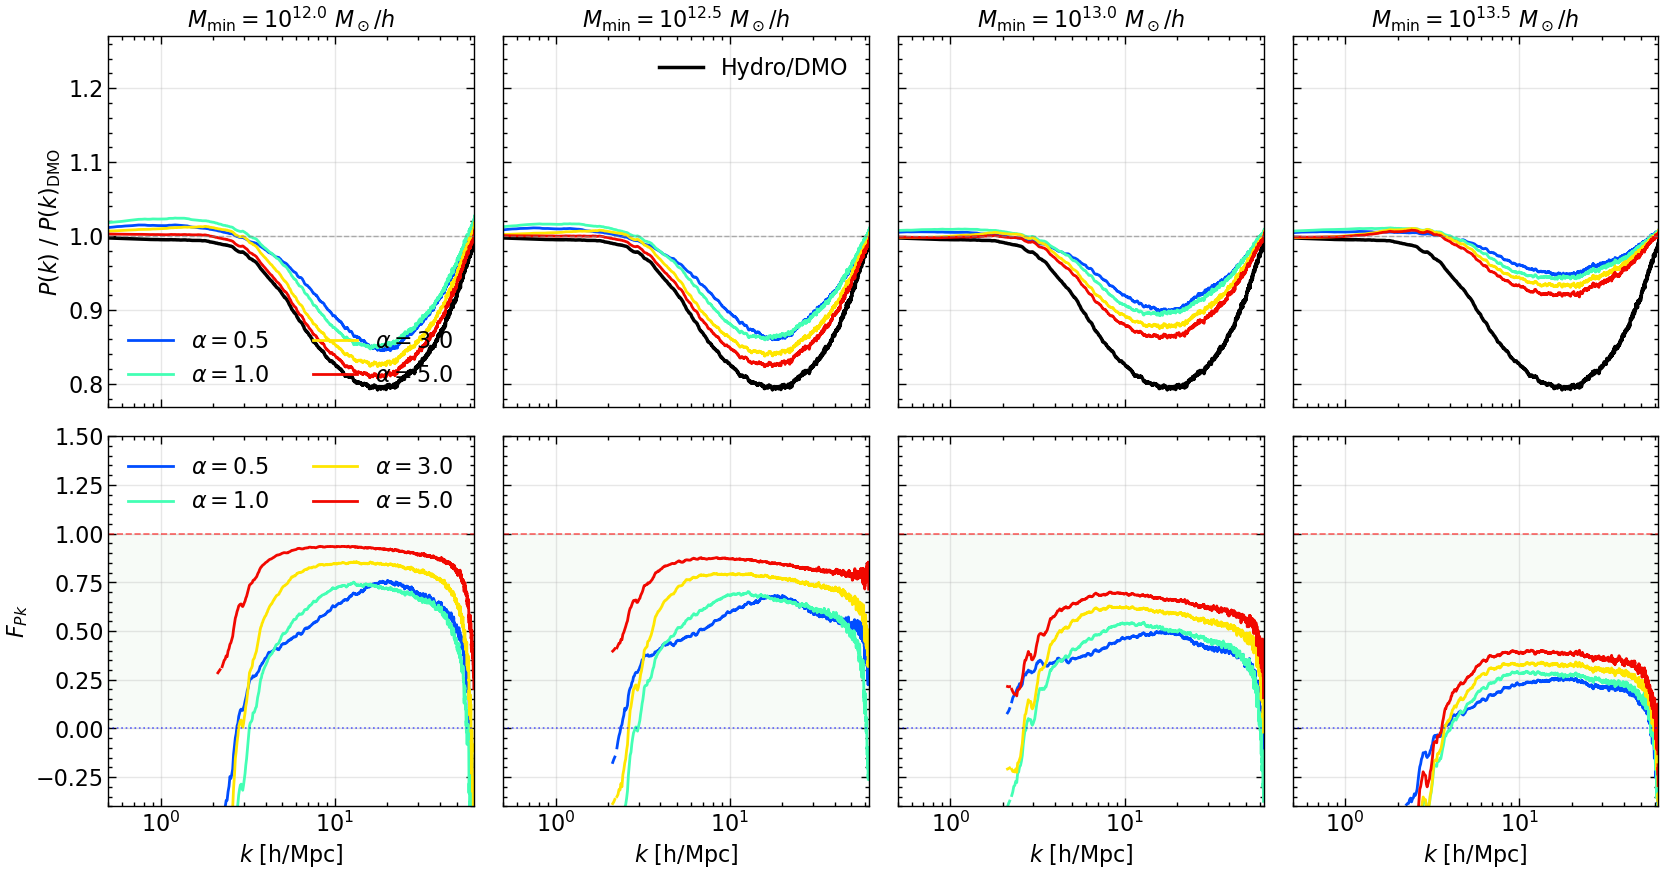

In [4]:
# Figure 1: Scale-dependent response (compare with notebook 06)
fig1 = ResponsePlotter.plot_scale_dependent_response(
    PK_CONFIG,
    density_loader,
    snapshot_idx=0,
    save_path=Path('./figures/test_scale_dependent_response.pdf')
)
plt.show()

Saved: figures/test_cumulative_summary.pdf


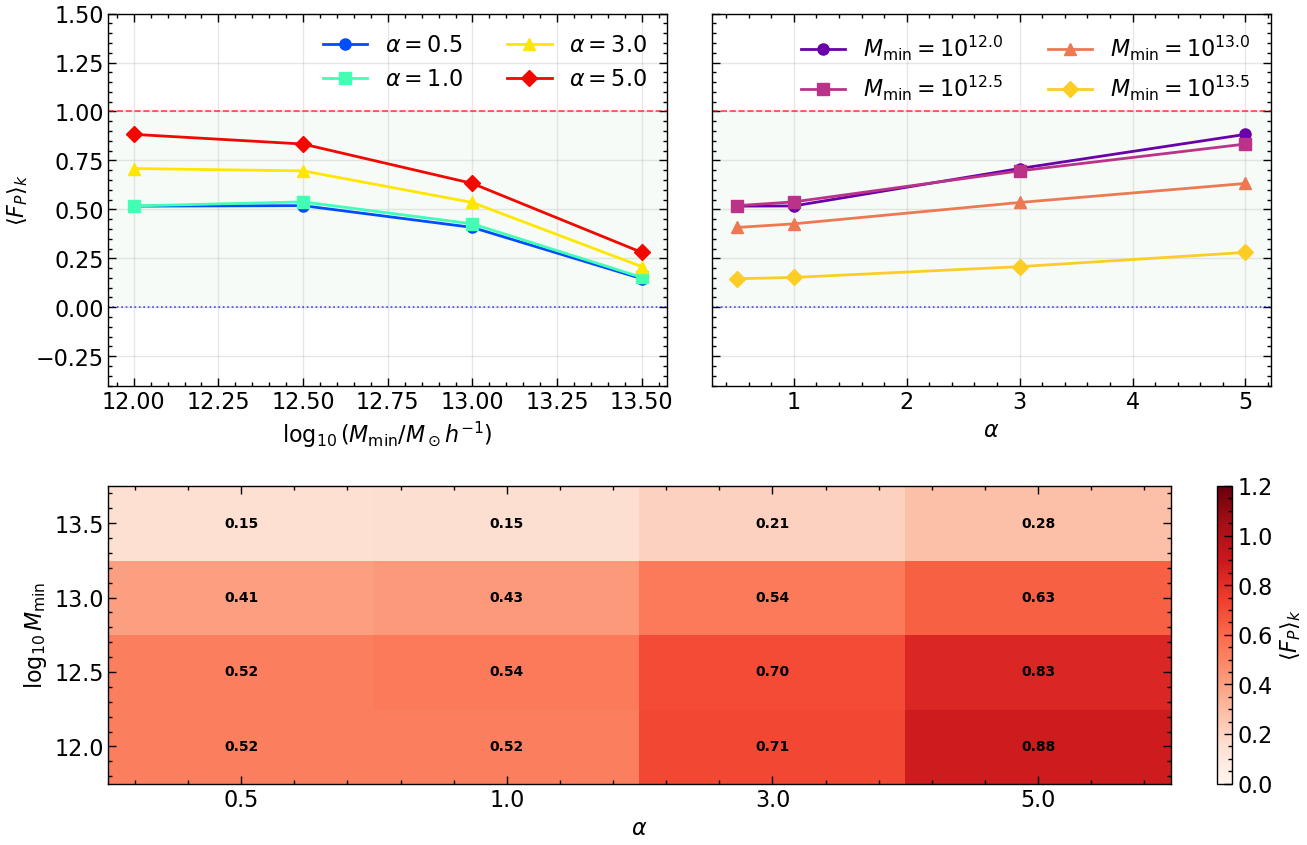

In [5]:
# Figure 2: Cumulative summary + heatmap
fig2 = ResponsePlotter.plot_cumulative_summary(
    PK_CONFIG,
    density_loader,
    snapshot_idx=0,
    save_path=Path('./figures/test_cumulative_summary.pdf')
)
plt.show()

Saved: figures/test_redshift_evolution.pdf


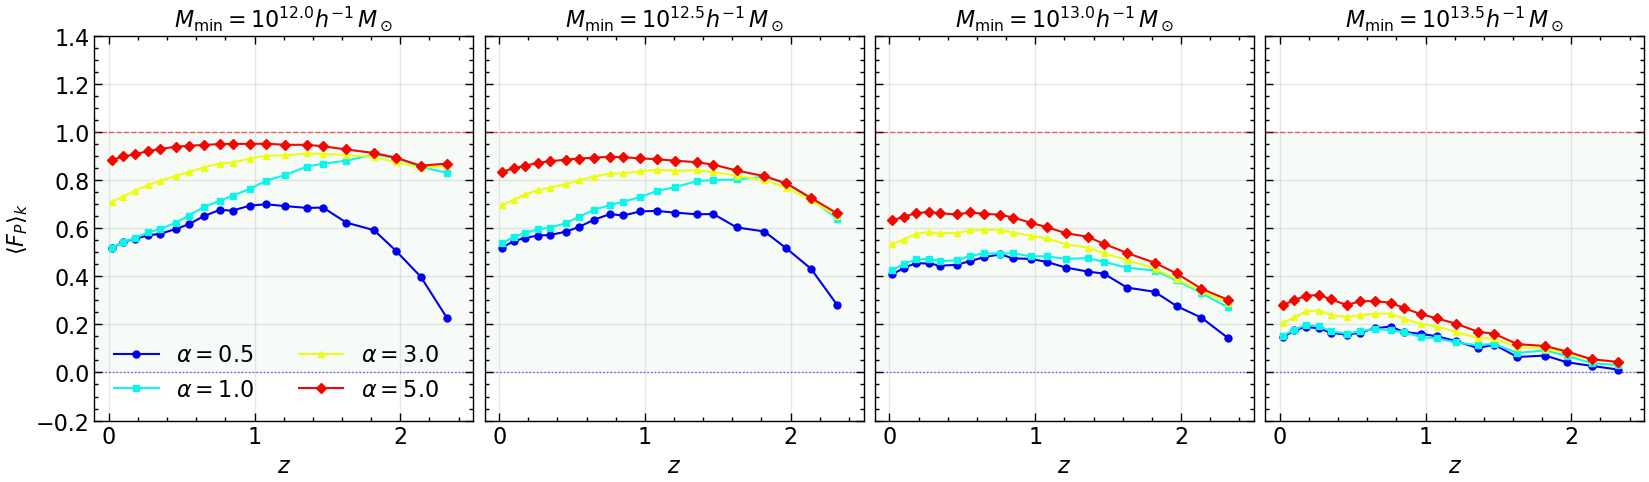

In [6]:
# Figure 3: Redshift evolution
fig3 = ResponsePlotter.plot_redshift_evolution(
    pk_cube,
    save_path=Path('./figures/test_redshift_evolution.pdf')
)
plt.show()

## Part 2: Kappa Statistics (C_ℓ)

Test with kappa convergence statistics using the pre-computed response data
in `response_analysis_output_kappabins/`.

In [3]:
# Check kappa response files
kappa_dir = Path('./response_analysis_output_kappabins')
if kappa_dir.exists():
    npz_files = list(kappa_dir.glob('response_C_ell_z*.npz'))
    pkl_files = list(kappa_dir.glob('response_C_ell_z*_dicts.pkl'))
    print(f"Found {len(npz_files)} C_ell NPZ files")
    print(f"Found {len(pkl_files)} C_ell PKL files")
    
    # List available statistics
    stat_types = set()
    for f in kappa_dir.glob('response_*_z01.npz'):
        stat = f.stem.replace('response_', '').replace('_z01', '')
        stat_types.add(stat)
    print(f"\nAvailable statistics: {sorted(stat_types)}")
else:
    print(f"⚠ Directory not found: {kappa_dir}")

Found 40 C_ell NPZ files
Found 40 C_ell PKL files

Available statistics: ['C_ell', 'V0', 'V1', 'V2', 'minima', 'pdf', 'peaks']


In [6]:
# Create kappa response loader for C_ell
if kappa_dir.exists():
    kappa_loader = KappaResponseLoader(kappa_dir, statistic='C_ell')
    
    # Test loading at z_idx=0 (corresponds to z01 files)
    dmo_kappa = kappa_loader.load('dmo', snapshot_idx=0)
    hydro_kappa = kappa_loader.load('hydro', snapshot_idx=0)
    
    if dmo_kappa:
        print(f"✓ DMO kappa loaded")
        print(f"  Keys: {list(dmo_kappa.keys())}")
        print(f"  ell range: {dmo_kappa['ell'].min():.0f} - {dmo_kappa['ell'].max():.0f}")
        print(f"  C_ell shape: {dmo_kappa['C_ell'].shape}")
    
    # Test loading a Replace model
    replace_test = kappa_loader.load('hydro_replace_Ml_1.00e12_Mu_inf_R_1.0', snapshot_idx=0)
    if replace_test:
        print(f"\n✓ Replace model loaded")
        print(f"  Keys: {list(replace_test.keys())}")
        print(f"  F_S (pre-computed): shape={replace_test['F_S'].shape}")
else:
    dmo_kappa = None

✓ DMO kappa loaded
  Keys: ['ell', 'C_ell', 'C_ell_err']
  ell range: 87 - 52134
  C_ell shape: (724,)

✓ Replace model loaded
  Keys: ['ell', 'C_ell', 'C_ell_err', 'F_S', 'F_S_err']
  F_S (pre-computed): shape=(724,)


In [7]:
# Build C_ell response cube using pre-computed data
# Note: The kappa files have 40 source z bins (z01-z40), not 20 snapshots

if kappa_dir.exists() and dmo_kappa is not None:
    # Use CELL_CONFIG but with KappaResponseLoader
    cell_cube = ResponseDataCube(CELL_CONFIG, kappa_loader, n_snapshots=40)
    cell_cube.build(verbose=True)

Building C_ell response cube: 4 masses × 4 radii × 40 snapshots
  Snapshot  0 (z=0.10): 16/16 valid
  Snapshot  1 (z=0.16): 16/16 valid
  Snapshot  2 (z=0.22): 16/16 valid
  Snapshot  3 (z=0.28): 16/16 valid
  Snapshot  4 (z=0.35): 16/16 valid
  Snapshot  5 (z=0.41): 16/16 valid
  Snapshot  6 (z=0.47): 16/16 valid
  Snapshot  7 (z=0.53): 16/16 valid
  Snapshot  8 (z=0.59): 16/16 valid
  Snapshot  9 (z=0.65): 16/16 valid
  Snapshot 10 (z=0.72): 16/16 valid
  Snapshot 11 (z=0.78): 16/16 valid
  Snapshot 12 (z=0.84): 16/16 valid
  Snapshot 13 (z=0.90): 16/16 valid
  Snapshot 14 (z=0.96): 16/16 valid
  Snapshot 15 (z=1.02): 16/16 valid
  Snapshot 16 (z=1.08): 16/16 valid
  Snapshot 17 (z=1.15): 16/16 valid
  Snapshot 18 (z=1.21): 16/16 valid
  Snapshot 19 (z=1.27): 16/16 valid
  Snapshot 20 (z=1.33): 16/16 valid
  Snapshot 21 (z=1.39): 16/16 valid
  Snapshot 22 (z=1.45): 16/16 valid
  Snapshot 23 (z=1.52): 16/16 valid
  Snapshot 24 (z=1.58): 16/16 valid
  Snapshot 25 (z=1.64): 16/16 valid


### C_ℓ Response Plots at z_source ~ 1 (z_idx = 20)

These plots mirror the P(k) plots from Part 1, but for the angular power spectrum C_ℓ.

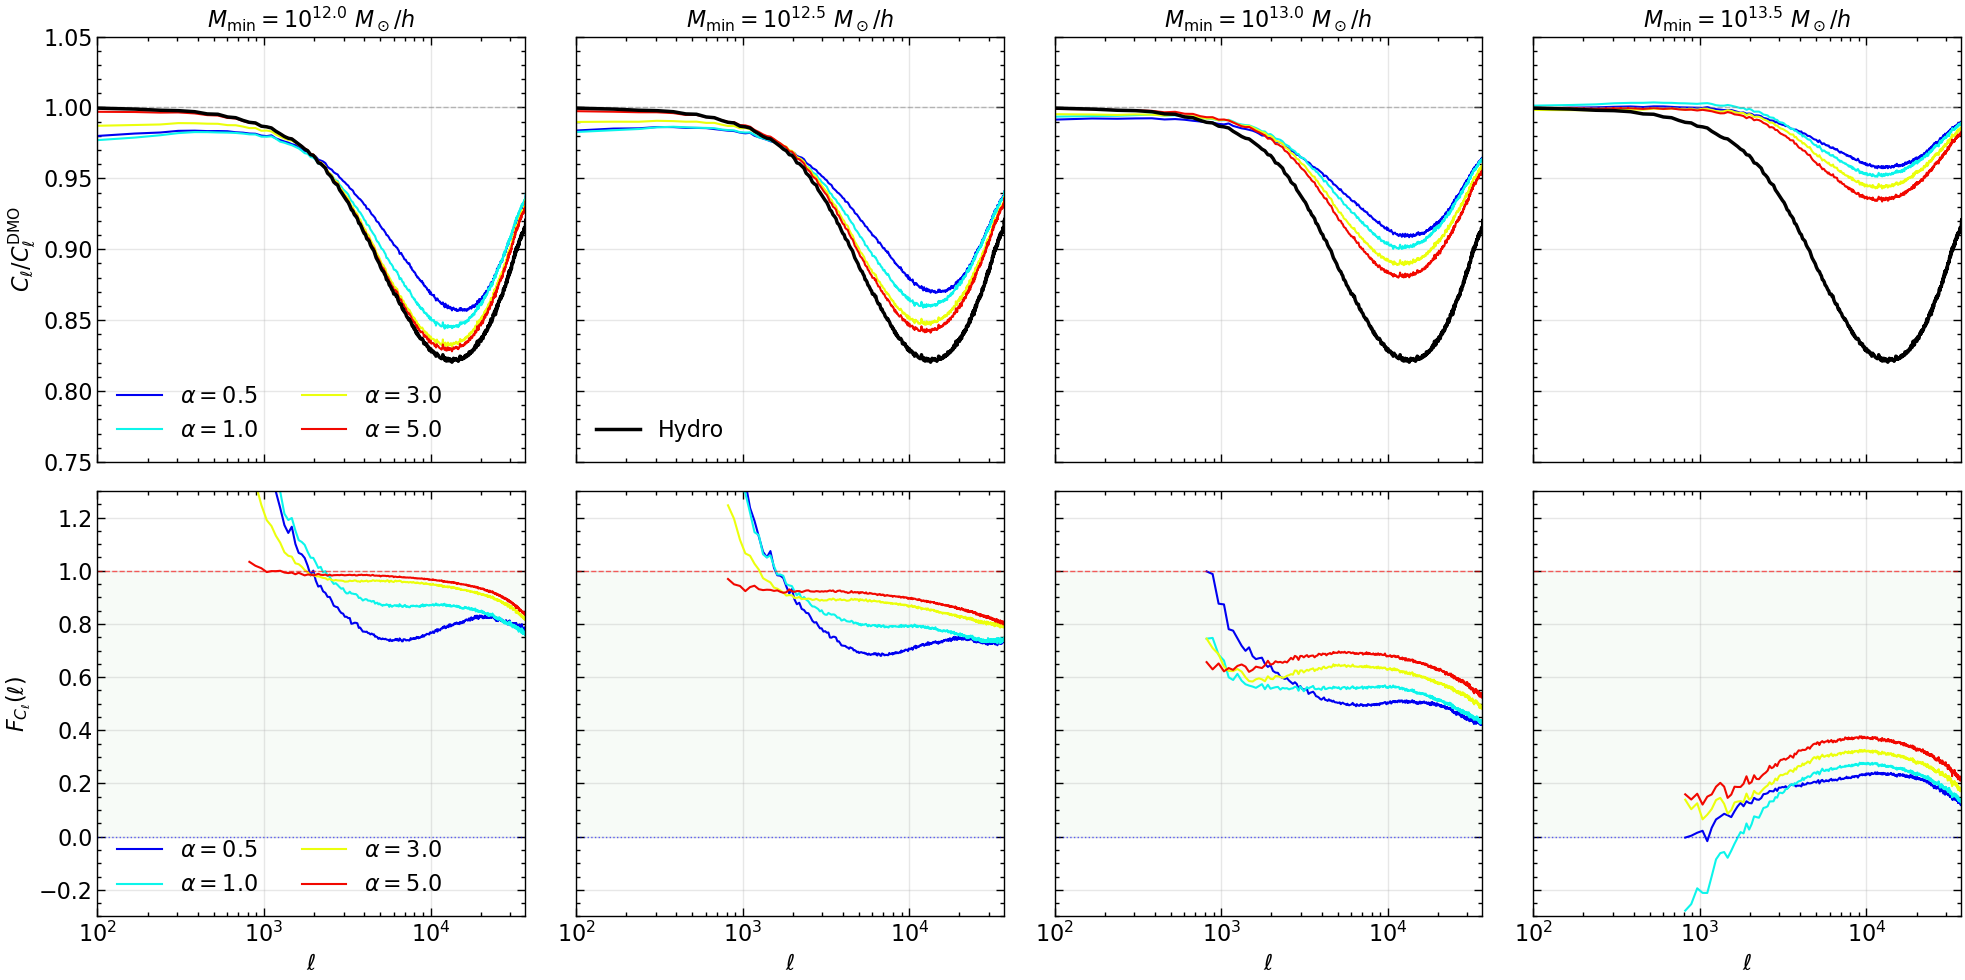

✓ Saved to figures/C_ell_scale_dependent_response_z1.pdf


In [8]:
# Figure 1: Scale-dependent C_ell response at z_source ~ 1 (z_idx = 20)
# Similar to the P(k) plot in Part 1

Z_IDX = 20  # Corresponds to source redshift z ~ 1
ELL_NYQUIST = 36864

if kappa_dir.exists():
    fig = plt.figure(figsize=(20, 10))
    
    # Create separate subplot grids for top and bottom rows with shared axes
    axes_top = [fig.add_subplot(2, 4, i+1) for i in range(4)]
    axes_bottom = [fig.add_subplot(2, 4, i+5) for i in range(4)]
    
    # Share x across all, share y within rows
    for i in range(1, 4):
        axes_top[i].sharex(axes_top[0])
        axes_top[i].sharey(axes_top[0])
        axes_bottom[i].sharex(axes_bottom[0])
        axes_bottom[i].sharey(axes_bottom[0])
    axes_bottom[0].sharex(axes_top[0])  # Share x between rows too
    
    colors_alpha = plt.cm.jet(np.linspace(0.1, 0.9, len(RADII)))
    
    # Load DMO and Hydro baselines at z_idx=20
    data_z20 = np.load(kappa_dir / f'response_C_ell_z{Z_IDX:02d}.npz')
    ell = data_z20['ell']
    S_D = data_z20['S_D']
    S_H = data_z20['S_H']
    
    for ax_idx, ml in enumerate(MASS_THRESHOLDS):
        # Top row: C_ell / C_ell_DMO (suppression)
        ax = axes_top[ax_idx]
        
        # Hydro baseline
        if ax_idx==1:
            ax.semilogx(ell, S_H / S_D, 'k-', lw=2.5, label='Hydro', zorder=10)
            ax.legend(loc='lower left')
        else:
            ax.semilogx(ell, S_H / S_D, 'k-', lw=2.5, zorder=10)
        
        # Replace models
        for r_idx, r in enumerate(RADII):
            model_name = f'hydro_replace_Ml_{ml}_Mu_inf_R_{r}'
            stats = kappa_loader.load(model_name, snapshot_idx=Z_IDX-1)  # z_idx=20 -> snapshot_idx=19
            if stats and 'C_ell' in stats:
                ax.semilogx(ell, stats['C_ell'] / S_D, lw=1.5, 
                           color=colors_alpha[r_idx], label=fr'$\alpha={r}$')
        
        ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.5)
        mass_log = np.log10(float(ml))
        ax.set_title(fr'$M_{{\rm min}}=10^{{{mass_log:.1f}}}\ M_\odot/h$')
        ax.set_xlim(100, ELL_NYQUIST)
        ax.set_ylim(0.75, 1.05)
        ax.grid(True, alpha=0.3)
        plt.setp(ax.get_xticklabels(), visible=False)

        
        if ax_idx == 0:
            ax.set_ylabel(r'$C_\ell / C_\ell^{\rm DMO}$')
            ax.legend(loc='lower left', ncol=2)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)
        
        # Bottom row: Response fraction F_S(ell)
        ax = axes_bottom[ax_idx]
        
        for r_idx, r in enumerate(RADII):
            model_name = f'hydro_replace_Ml_{ml}_Mu_inf_R_{r}'
            stats = kappa_loader.load(model_name, snapshot_idx=Z_IDX-1)
            if stats and 'F_S' in stats:
                ax.semilogx(ell, stats['F_S'], lw=1.5, 
                           color=colors_alpha[r_idx], label=fr'$\alpha={r}$')
        
        ax.axhline(1.0, color='red', ls='--', lw=1, alpha=0.6)
        ax.axhline(0.0, color='blue', ls=':', lw=1, alpha=0.6)
        ax.axhspan(0, 1, alpha=0.03, color='green')
        ax.set_xlabel(r'$\ell$')
        ax.set_xlim(100, ELL_NYQUIST)
        ax.set_ylim(-0.3, 1.3)
        ax.grid(True, alpha=0.3)
        
        if ax_idx == 0:
            ax.set_ylabel(r'$F_{C_\ell}(\ell)$')
            ax.legend(loc='lower left', ncol=2)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)
    
    # plt.suptitle(fr'Scale-dependent $C_\ell$ Response at $z_{{\rm source}} \approx 1$ (z_idx={Z_IDX})', 
    #              y=1.01, fontsize=14)
    plt.tight_layout()
    plt.savefig('./figures/C_ell_scale_dependent_response_z1.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    
    print(f"✓ Saved to figures/C_ell_scale_dependent_response_z1.pdf")

Averaging over 501 ell bins where |C_H/C_D - 1| > 1%
  ell range: 817 - 36826


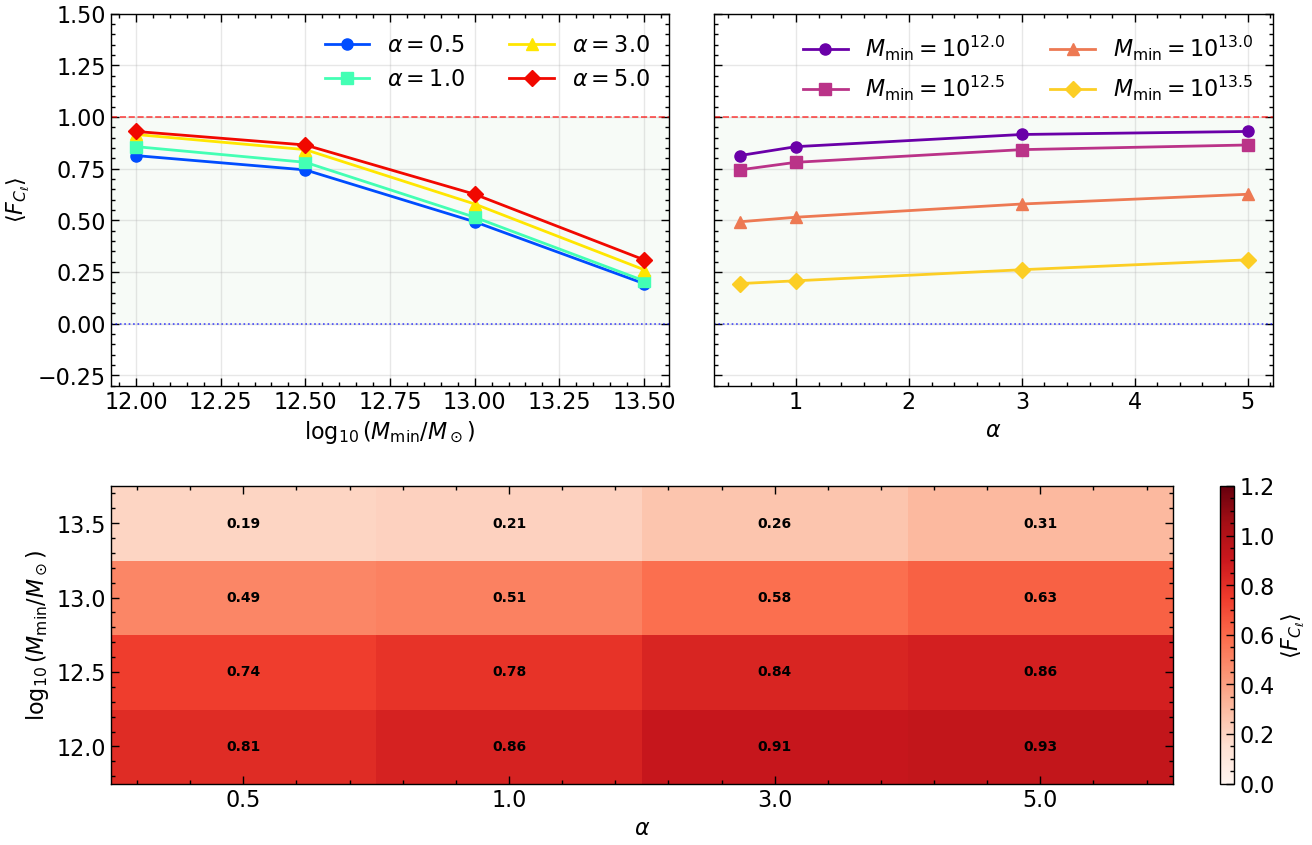

✓ Saved to figures/C_ell_cumulative_summary_z1.pdf


In [16]:
# Figure 2: Cumulative C_ell summary + Heatmap at z_source ~ 1
# Matching the P(k) cumulative summary layout from Part 1

if kappa_dir.exists():
    # Load DMO and Hydro baselines to determine where baryonic effects are significant
    data_z20 = np.load(kappa_dir / f'response_C_ell_z{Z_IDX:02d}.npz')
    ell_base = data_z20['ell']
    S_D_base = data_z20['S_D']
    S_H_base = data_z20['S_H']
    
    # Mask where |C_hydro/C_dmo - 1| > 0.01 (>1% baryonic effect) and ell <= ell_Nyquist
    baryonic_effect = np.abs(S_H_base / S_D_base - 1)
    mask_significant = (baryonic_effect > 0.01) & (ell_base <= ELL_NYQUIST)
    
    print(f"Averaging over {np.sum(mask_significant)} ell bins where |C_H/C_D - 1| > 1%")
    print(f"  ell range: {ell_base[mask_significant].min():.0f} - {ell_base[mask_significant].max():.0f}")
    
    # Compute mean F_S for each model at z_idx=20
    F_values = np.zeros((len(MASS_THRESHOLDS), len(RADII)))
    
    for i, ml in enumerate(MASS_THRESHOLDS):
        for j, r in enumerate(RADII):
            model_name = f'hydro_replace_Ml_{ml}_Mu_inf_R_{r}'
            stats = kappa_loader.load(model_name, snapshot_idx=Z_IDX-1)
            if stats and 'F_S' in stats:
                # Mean F_S where baryonic effect is significant (>1%)
                F_S = stats['F_S']
                F_values[i, j] = np.nanmean(F_S[mask_significant])
    
    # Create figure with gridspec like the P(k) version
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.8], hspace=0.3, wspace=0.08)
    
    colors_alpha = plt.cm.jet(np.linspace(0.2, 0.9, len(RADII)))
    colors_mass = plt.cm.plasma(np.linspace(0.2, 0.9, len(MASS_THRESHOLDS)))
    markers = ['o', 's', '^', 'D']
    
    # Row 0: Line plots
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
    
    # Left: fixed α, varying M_min
    for r_idx, r in enumerate(RADII):
        means = F_values[:, r_idx]
        ax0.plot(LOG_MASS, means, marker=markers[r_idx], color=colors_alpha[r_idx],
                lw=2, ms=8, label=fr'$\alpha={r}$')
    ax0.set_xlabel(r'$\log_{10}(M_{\rm min}/M_\odot)$')
    ax0.set_ylabel(r'$\langle F_{C_\ell} \rangle$')
    
    # Right: fixed M_min, varying α
    for m_idx, ml in enumerate(MASS_THRESHOLDS):
        means = F_values[m_idx, :]
        ax1.plot(ALPHA_VALUES, means, marker=markers[m_idx], color=colors_mass[m_idx],
                lw=2, ms=8, label=r'$M_{\rm min}=$' + MASS_LABELS[m_idx])
    ax1.set_xlabel(r'$\alpha$')
    plt.setp(ax1.get_yticklabels(), visible=False)
    
    for ax in (ax0, ax1):
        ax.axhline(1.0, color='red', ls='--', lw=1.2, alpha=0.7)
        ax.axhline(0.0, color='blue', ls=':', lw=1.2, alpha=0.7)
        ax.set_ylim(-0.3, 1.5)
        ax.grid(True, alpha=0.3)
        ax.axhspan(0, 1, alpha=0.03, color='green')
    ax0.legend(loc='best', ncol=2)
    ax1.legend(loc='best', ncol=2)
    
    # Row 1: Heatmap spanning both columns
    ax2 = fig.add_subplot(gs[1, :])
    im = ax2.imshow(F_values, cmap='Reds', vmin=0, vmax=1.2, aspect='auto', origin='lower')
    ax2.set_xticks(range(len(RADII)))
    ax2.set_xticklabels(RADII)
    ax2.set_yticks(range(len(MASS_THRESHOLDS)))
    ax2.set_yticklabels([f'{m:.1f}' for m in LOG_MASS])
    ax2.set_xlabel(r'$\alpha$')
    ax2.set_ylabel(r'$\log_{10}(M_{\rm min} / M_\odot)$')
    ax2.grid(False)
    
    # Add text annotations
    for i in range(len(MASS_THRESHOLDS)):
        for j in range(len(RADII)):
            val = F_values[i, j]
            if not np.isnan(val):
                ax2.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=10, fontweight='bold')
    
    cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\langle F_{C_\ell} \rangle$')
    
    plt.tight_layout()
    plt.savefig('./figures/C_ell_cumulative_summary_z1.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    
    print(f"✓ Saved to figures/C_ell_cumulative_summary_z1.pdf")

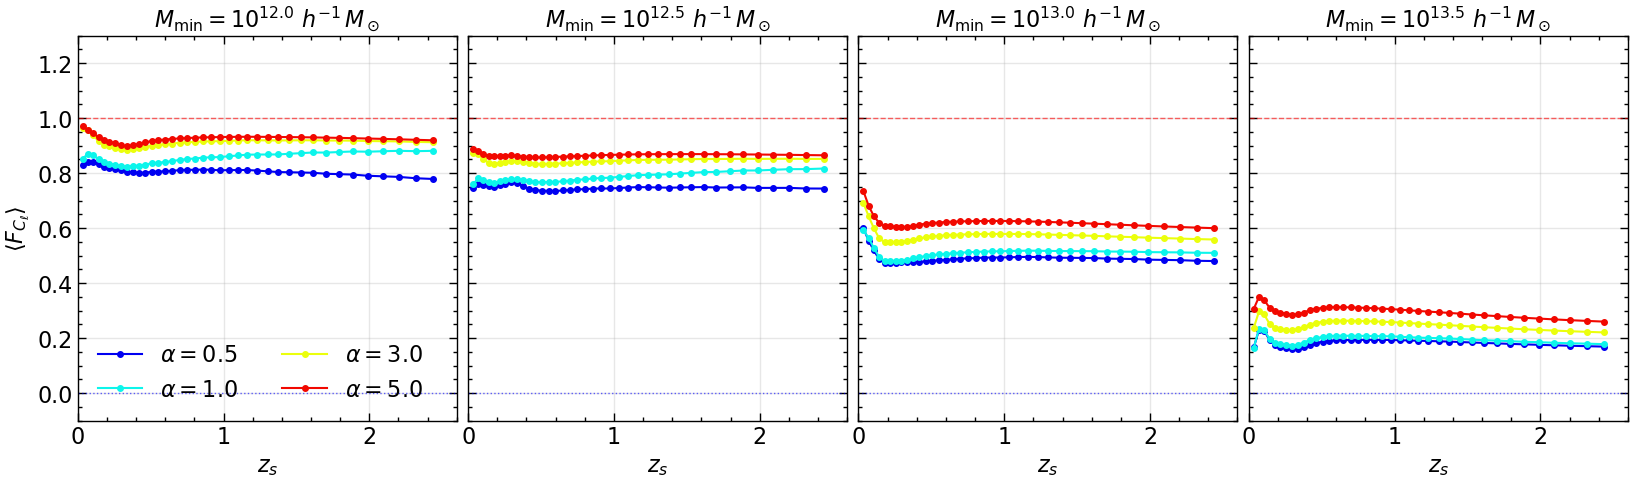

✓ Saved to figures/C_ell_redshift_evolution.pdf


In [21]:
# Figure 3: Redshift evolution of C_ell response
# Similar to the redshift evolution plot in Part 1

# Source plane redshifts (z_s) for S1-S40
SOURCE_REDSHIFTS = np.array([
    0.034, 0.070, 0.105, 0.142, 0.179, 0.216, 0.255, 0.294, 0.335, 0.376,
    0.418, 0.462, 0.506, 0.552, 0.599, 0.648, 0.698, 0.749, 0.803, 0.858,
    0.914, 0.973, 1.034, 1.097, 1.163, 1.231, 1.302, 1.375, 1.452, 1.532,
    1.615, 1.703, 1.794, 1.889, 1.989, 2.094, 2.203, 2.319, 2.440, 2.568
])

if kappa_dir.exists():
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True,
                              gridspec_kw={'wspace': 0.03})
    
    colors_alpha = plt.cm.jet(np.linspace(0.1, 0.9, len(RADII)))
    
    for ax_idx, ml in enumerate(MASS_THRESHOLDS):
        mass_log = np.log10(float(ml))
        ax = axes[ax_idx]
        
        z_range = np.arange(1, 40)
        z_redshifts = SOURCE_REDSHIFTS[:39]  # Redshifts for z_idx 1-39
        
        for r_idx, r in enumerate(RADII):
            model_name = f'hydro_replace_Ml_{ml}_Mu_inf_R_{r}'
            F_vs_z = []
            
            for z_idx in z_range:
                stats = kappa_loader.load(model_name, snapshot_idx=z_idx-1)
                # Load DMO/Hydro baselines for this redshift to get significant ell mask
                data_z = np.load(kappa_dir / f'response_C_ell_z{z_idx:02d}.npz')
                ell_z = data_z['ell']
                S_D_z = data_z['S_D']
                S_H_z = data_z['S_H']
                
                # Mask where |C_hydro/C_dmo - 1| > 0.01 (>1% baryonic effect)
                baryonic_effect_z = np.abs(S_H_z / S_D_z - 1)
                mask_significant_z = (baryonic_effect_z > 0.01) & (ell_z <= ELL_NYQUIST)
                
                if stats and 'F_S' in stats and np.sum(mask_significant_z) > 0:
                    F_S = stats['F_S']
                    F_vs_z.append(np.nanmean(F_S[mask_significant_z]))
                else:
                    F_vs_z.append(np.nan)
            
            ax.plot(z_redshifts, F_vs_z, 'o-', color=colors_alpha[r_idx], 
                   lw=1.5, markersize=4, label=fr'$\alpha={r}$')
        
        ax.axhline(1.0, color='red', ls='--', lw=1, alpha=0.6)
        ax.axhline(0.0, color='blue', ls=':', lw=1, alpha=0.6)
        ax.set_xlabel(r'$z_s$')
        ax.set_xlim(0, 2.6)
        ax.set_ylim(-0.1, 1.3)
        ax.grid(True, alpha=0.3)
        ax.set_title(fr'$M_{{\rm min}}=10^{{{mass_log:.1f}}}\ h^{{-1}}\,M_\odot$')

        
        if ax_idx == 0:
            ax.set_ylabel(r'$\langle F_{C_\ell} \rangle$')
            ax.legend(loc='lower left', ncols=2)

    plt.tight_layout()
    plt.savefig('./figures/C_ell_redshift_evolution.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    
    print(f"✓ Saved to figures/C_ell_redshift_evolution.pdf")

## Part 3: Peak Counts

Now we repeat the same 3 plots for weak lensing peak counts. The x-axis is κ/σ (SNR) instead of ℓ.

In [17]:
# Load peak counts response data
if kappa_dir.exists():
    peaks_loader = KappaResponseLoader(kappa_dir, statistic='peaks')
    
    # Test loading at z_idx=19 (corresponds to z20 files, z_s ~ 0.86)
    dmo_peaks = peaks_loader.load('dmo', snapshot_idx=23)
    hydro_peaks = peaks_loader.load('hydro', snapshot_idx=23)
    
    if dmo_peaks:
        print(f"✓ DMO peaks loaded")
        print(f"  Keys: {list(dmo_peaks.keys())}")
        if 'kappa_mid' in dmo_peaks:
            print(f"  kappa_mid range: {dmo_peaks['kappa_mid'].min():.2f} - {dmo_peaks['kappa_mid'].max():.2f}")
        print(f"  peaks shape: {dmo_peaks['peaks'].shape}")
    
    # Test loading a Replace model
    replace_peaks_test = peaks_loader.load('hydro_replace_Ml_1.00e12_Mu_inf_R_1.0', snapshot_idx=19)
    if replace_peaks_test:
        print(f"\n✓ Replace model peaks loaded")
        print(f"  Keys: {list(replace_peaks_test.keys())}")
        print(f"  F_S (pre-computed): shape={replace_peaks_test['F_S'].shape}")
else:
    dmo_peaks = None

✓ DMO peaks loaded
  Keys: ['kappa_mid', 'peaks', 'peaks_err']
  kappa_mid range: -0.04 - 0.20
  peaks shape: (25,)

✓ Replace model peaks loaded
  Keys: ['kappa_mid', 'peaks', 'peaks_err', 'F_S', 'F_S_err']
  F_S (pre-computed): shape=(25,)


In [ ]:
# Figure 1: Scale-dependent peak count response at z_source ~ 0.86 (z_idx = 20)
# NEW: Compute peak counts directly from smoothed convergence maps
# Using all 1000 realizations (10 LPs × 100 runs), summing counts across all realizations

import h5py
from tqdm.notebook import tqdm

Z_IDX_PEAKS = 20  # Corresponds to source redshift z ~ 0.86 (kappa20.dat)
SMOOTHING_PIX = 5  # 1 arcmin smoothing

# Kappa bins for peak counts
N_BINS = 20
kappa_bins = np.linspace(-0.02, 0.15, N_BINS + 1)
kappa_mid = 0.5 * (kappa_bins[:-1] + kappa_bins[1:])

# Models to process: DMO, Hydro, and cumulative Replace models
cumulative_models = [
    'dmo', 'hydro',
    'hydro_replace_Ml_1.00e12_Mu_inf_R_0.5',
    'hydro_replace_Ml_1.00e12_Mu_inf_R_1.0',
    'hydro_replace_Ml_1.00e12_Mu_inf_R_3.0',
    'hydro_replace_Ml_1.00e12_Mu_inf_R_5.0',
    'hydro_replace_Ml_3.16e12_Mu_inf_R_0.5',
    'hydro_replace_Ml_3.16e12_Mu_inf_R_1.0',
    'hydro_replace_Ml_3.16e12_Mu_inf_R_3.0',
    'hydro_replace_Ml_3.16e12_Mu_inf_R_5.0',
    'hydro_replace_Ml_1.00e13_Mu_inf_R_0.5',
    'hydro_replace_Ml_1.00e13_Mu_inf_R_1.0',
    'hydro_replace_Ml_1.00e13_Mu_inf_R_3.0',
    'hydro_replace_Ml_1.00e13_Mu_inf_R_5.0',
    'hydro_replace_Ml_3.16e13_Mu_inf_R_0.5',
    'hydro_replace_Ml_3.16e13_Mu_inf_R_1.0',
    'hydro_replace_Ml_3.16e13_Mu_inf_R_3.0',
    'hydro_replace_Ml_3.16e13_Mu_inf_R_5.0',
]

# Storage for summed counts and per-realization counts (for error estimation)
summed_counts = {m: np.zeros(N_BINS) for m in cumulative_models}
all_counts = {m: [] for m in cumulative_models}  # List of counts per realization
n_realizations = 0

print(f"Computing smoothed peak counts (σ = {SMOOTHING_PIX} pixels = 1 arcmin)")
print(f"Loading from {RT_DIR}")
print(f"Processing {len(cumulative_models)} models × 10 LPs × 100 runs = {len(cumulative_models) * 1000} maps\n")

# Progress bar for all models
for model in tqdm(cumulative_models, desc="Models"):
    model_dir = RT_DIR / model
    if not model_dir.exists():
        print(f"  ⚠ Skipping {model} - directory not found")
        continue
    
    for lp_idx in range(10):  # LP_00 to LP_09
        lp_dir = model_dir / f'LP_{lp_idx:02d}'
        if not lp_dir.exists():
            continue
            
        for run_idx in range(1, 101):  # run001 to run100
            kappa_file = lp_dir / f'run{run_idx:03d}' / f'kappa{Z_IDX_PEAKS:02d}.dat'
            if not kappa_file.exists():
                continue
            
            # Load kappa map
            kappa = load_kappa_map(model, lp_idx=lp_idx, run_idx=run_idx, source_idx=Z_IDX_PEAKS)
            if kappa is None:
                continue
            
            # Smooth
            kappa_sm = smooth_kappa(kappa, SMOOTHING_PIX)
            
            # Find peaks
            peaks = find_peaks(kappa_sm)
            
            # Histogram
            counts, _ = np.histogram(peaks, bins=kappa_bins)
            summed_counts[model] += counts
            all_counts[model].append(counts)
            
            if model == 'dmo':
                n_realizations += 1

print(f"\n✓ Processed {n_realizations} realizations per model")
print(f"✓ Total peaks per model (summed): DMO={summed_counts['dmo'].sum():.0f}, Hydro={summed_counts['hydro'].sum():.0f}")

Computing smoothed peak counts (σ = 5 pixels = 1 arcmin)
Loading from /mnt/home/mlee1/ceph/hydro_replace_RT/L205n2500TNG
Processing 18 models × 10 LPs × 100 runs = 18000 maps



Models:   0%|          | 0/18 [00:00<?, ?it/s]

Averaging over 19 kappa bins where |N_H/N_D - 1| > 1%
  kappa range: -0.02 - 0.16


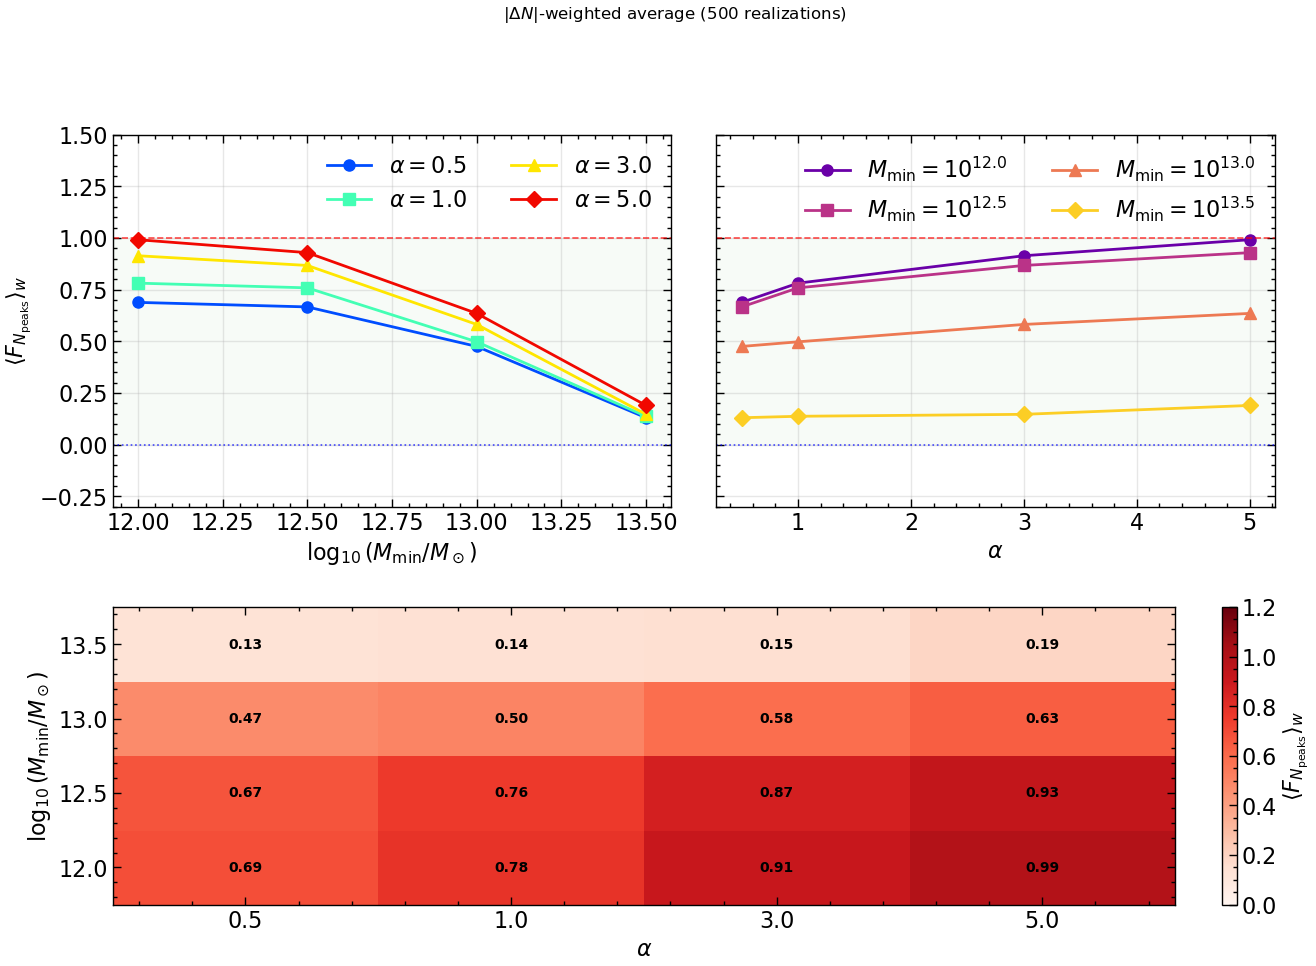

✓ Saved to figures/peaks_cumulative_summary_z1.pdf
Note: Using |ΔN|-weighted averaging to reduce noise from low-count bins


In [19]:
# Figure 2: Cumulative peak count summary + Heatmap at z_source ~ 0.86
# Using |Delta_S|-weighted averaging to reduce noise

if kappa_dir.exists() and dmo_peaks is not None:
    # Load DMO and Hydro baselines to determine where baryonic effects are significant
    data_z20_peaks = np.load(kappa_dir / f'response_peaks_z{Z_IDX_PEAKS:02d}.npz', allow_pickle=True)
    kappa_mid = data_z20_peaks['kappa_mid']
    S_D_peaks = data_z20_peaks['S_D']
    S_H_peaks = data_z20_peaks['S_H']
    Delta_S_peaks = S_H_peaks - S_D_peaks
    
    # Mask where |N_hydro/N_dmo - 1| > 0.01 (>1% baryonic effect) and counts > 0
    valid_dmo = S_D_peaks > 0
    baryonic_effect_peaks = np.where(valid_dmo, np.abs(S_H_peaks / S_D_peaks - 1), 0)
    mask_significant_peaks = (baryonic_effect_peaks > 0.01) & valid_dmo
    
    print(f"Averaging over {np.sum(mask_significant_peaks)} kappa bins where |N_H/N_D - 1| > 1%")
    if np.sum(mask_significant_peaks) > 0:
        print(f"  kappa range: {kappa_mid[mask_significant_peaks].min():.2f} - {kappa_mid[mask_significant_peaks].max():.2f}")
    
    # Compute |Delta_S|-weighted mean F_S for each model at z_idx=20
    F_values_peaks = np.zeros((len(MASS_THRESHOLDS), len(RADII)))
    
    for i, ml in enumerate(MASS_THRESHOLDS):
        for j, r in enumerate(RADII):
            model_name = f'hydro_replace_Ml_{ml}_Mu_inf_R_{r}'
            stats = peaks_loader.load(model_name, snapshot_idx=Z_IDX_PEAKS-1)
            if stats and 'F_S' in stats and np.sum(mask_significant_peaks) > 0:
                F_S = stats['F_S']
                # Weighted mean by |Delta_S| (signal strength)
                weights = np.abs(Delta_S_peaks).copy()
                weights[~mask_significant_peaks] = 0
                weights[np.isnan(F_S)] = 0
                if weights.sum() > 0:
                    F_values_peaks[i, j] = np.nansum(weights * F_S) / np.sum(weights)
    
    # Create figure with gridspec like the C_ell version
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.8], hspace=0.3, wspace=0.08)
    
    colors_alpha = plt.cm.jet(np.linspace(0.2, 0.9, len(RADII)))
    colors_mass = plt.cm.plasma(np.linspace(0.2, 0.9, len(MASS_THRESHOLDS)))
    markers = ['o', 's', '^', 'D']
    
    # Row 0: Line plots
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
    
    # Left: fixed α, varying M_min
    for r_idx, r in enumerate(RADII):
        means = F_values_peaks[:, r_idx]
        ax0.plot(LOG_MASS, means, marker=markers[r_idx], color=colors_alpha[r_idx],
                lw=2, ms=8, label=fr'$\alpha={r}$')
    ax0.set_xlabel(r'$\log_{10}(M_{\rm min}/M_\odot)$')
    ax0.set_ylabel(r'$\langle F_{N_{\rm peaks}} \rangle_w$')
    
    # Right: fixed M_min, varying α
    for m_idx, ml in enumerate(MASS_THRESHOLDS):
        means = F_values_peaks[m_idx, :]
        ax1.plot(ALPHA_VALUES, means, marker=markers[m_idx], color=colors_mass[m_idx],
                lw=2, ms=8, label=r'$M_{\rm min}=$' + MASS_LABELS[m_idx])
    ax1.set_xlabel(r'$\alpha$')
    plt.setp(ax1.get_yticklabels(), visible=False)
    
    for ax in (ax0, ax1):
        ax.axhline(1.0, color='red', ls='--', lw=1.2, alpha=0.7)
        ax.axhline(0.0, color='blue', ls=':', lw=1.2, alpha=0.7)
        ax.set_ylim(-0.3, 1.5)
        ax.grid(True, alpha=0.3)
        ax.axhspan(0, 1, alpha=0.03, color='green')
    ax0.legend(loc='best', ncol=2)
    ax1.legend(loc='best', ncol=2)
    
    # Row 1: Heatmap spanning both columns
    ax2 = fig.add_subplot(gs[1, :])
    im = ax2.imshow(F_values_peaks, cmap='Reds', vmin=0, vmax=1.2, aspect='auto', origin='lower')
    ax2.set_xticks(range(len(RADII)))
    ax2.set_xticklabels(RADII)
    ax2.set_yticks(range(len(MASS_THRESHOLDS)))
    ax2.set_yticklabels([f'{m:.1f}' for m in LOG_MASS])
    ax2.set_xlabel(r'$\alpha$')
    ax2.set_ylabel(r'$\log_{10}(M_{\rm min} / M_\odot)$')
    ax2.grid(False)
    
    # Add text annotations
    for i in range(len(MASS_THRESHOLDS)):
        for j in range(len(RADII)):
            val = F_values_peaks[i, j]
            if not np.isnan(val):
                ax2.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=10, fontweight='bold')
    
    cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\langle F_{N_{\rm peaks}} \rangle_w$')
    
    plt.suptitle(r'$|\Delta N|$-weighted average (500 realizations)', y=1.01, fontsize=12)
    plt.tight_layout()
    plt.savefig('./figures/peaks_cumulative_summary_z1.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    
    print(f"✓ Saved to figures/peaks_cumulative_summary_z1.pdf")
    print(f"Note: Using |ΔN|-weighted averaging to reduce noise from low-count bins")

## Direct Peak Count Analysis from Convergence Maps

Let's load convergence maps directly and analyze:
1. Effect of smoothing on peak counts
2. Effect of LSST-like survey noise
3. Comparison of DMO vs Hydro vs Replace models

In [22]:
# Load convergence maps directly from ray-tracing output
import struct
from scipy.ndimage import gaussian_filter
from scipy.ndimage import maximum_filter

RT_DIR = Path('/mnt/home/mlee1/ceph/hydro_replace_RT/L205n2500TNG')

def load_kappa_map(model, lp_idx=0, run_idx=1, source_idx=20):
    """Load a convergence map from lux ray-tracing output.
    
    File format (Fortran-style):
    - int32(grid_size) [header]
    - float64[grid_size × grid_size] [data]
    - int32(grid_size) [footer]
    """
    filepath = RT_DIR / model / f'LP_{lp_idx:02d}' / f'run{run_idx:03d}' / f'kappa{source_idx:02d}.dat'
    if not filepath.exists():
        print(f"File not found: {filepath}")
        return None
    
    with open(filepath, 'rb') as f:
        # Read header (grid size as int32)
        header = np.fromfile(f, dtype=np.int32, count=1)[0]
        # Read kappa data
        kappa = np.fromfile(f, dtype=np.float64, count=header*header)
        # Read footer (should match header)
        footer = np.fromfile(f, dtype=np.int32, count=1)[0]
    
    if header != footer:
        print(f"Warning: header ({header}) != footer ({footer})")
    
    kappa = kappa.reshape(header, header)
    return kappa

def find_peaks(kappa_map, threshold=None):
    """Find peaks in a kappa map using local maximum detection."""
    # Local maximum filter (3x3 neighborhood)
    local_max = maximum_filter(kappa_map, size=3)
    peaks_mask = (kappa_map == local_max)
    
    # Get peak values
    peak_values = kappa_map[peaks_mask]
    
    if threshold is not None:
        peak_values = peak_values[peak_values > threshold]
    
    return peak_values

def add_survey_noise(kappa_map, sigma_noise=0.026):
    """Add Gaussian shape noise typical of LSST-like surveys.
    
    Parameters:
    -----------
    sigma_noise : float
        Shape noise per pixel. For LSST with n_gal ~ 27/arcmin^2 and 
        σ_ε ~ 0.26, for 205 Mpc/h box at z~1 with 1024 pixels,
        pixel scale ~ 0.2 arcmin, so σ_pixel ~ 0.026
    """
    noise = np.random.normal(0, sigma_noise, kappa_map.shape)
    return kappa_map + noise

def smooth_kappa(kappa_map, sigma_pix):
    """Apply Gaussian smoothing to kappa map.
    
    Parameters:
    -----------
    sigma_pix : float
        Smoothing scale in pixels
    """
    return gaussian_filter(kappa_map, sigma=sigma_pix)

# Test loading a map
print("Loading test kappa map...")
kappa_dmo = load_kappa_map('dmo', lp_idx=0, run_idx=1, source_idx=20)
if kappa_dmo is not None:
    print(f"✓ Loaded kappa map: shape = {kappa_dmo.shape}")
    print(f"  kappa range: {kappa_dmo.min():.4f} to {kappa_dmo.max():.4f}")
    print(f"  kappa mean: {kappa_dmo.mean():.6f}, std: {kappa_dmo.std():.4f}")

Loading test kappa map...
✓ Loaded kappa map: shape = (1024, 1024)
  kappa range: -0.0287 to 0.7053
  kappa mean: 0.000262, std: 0.0198


=== Effect of Smoothing on Peak Counts ===



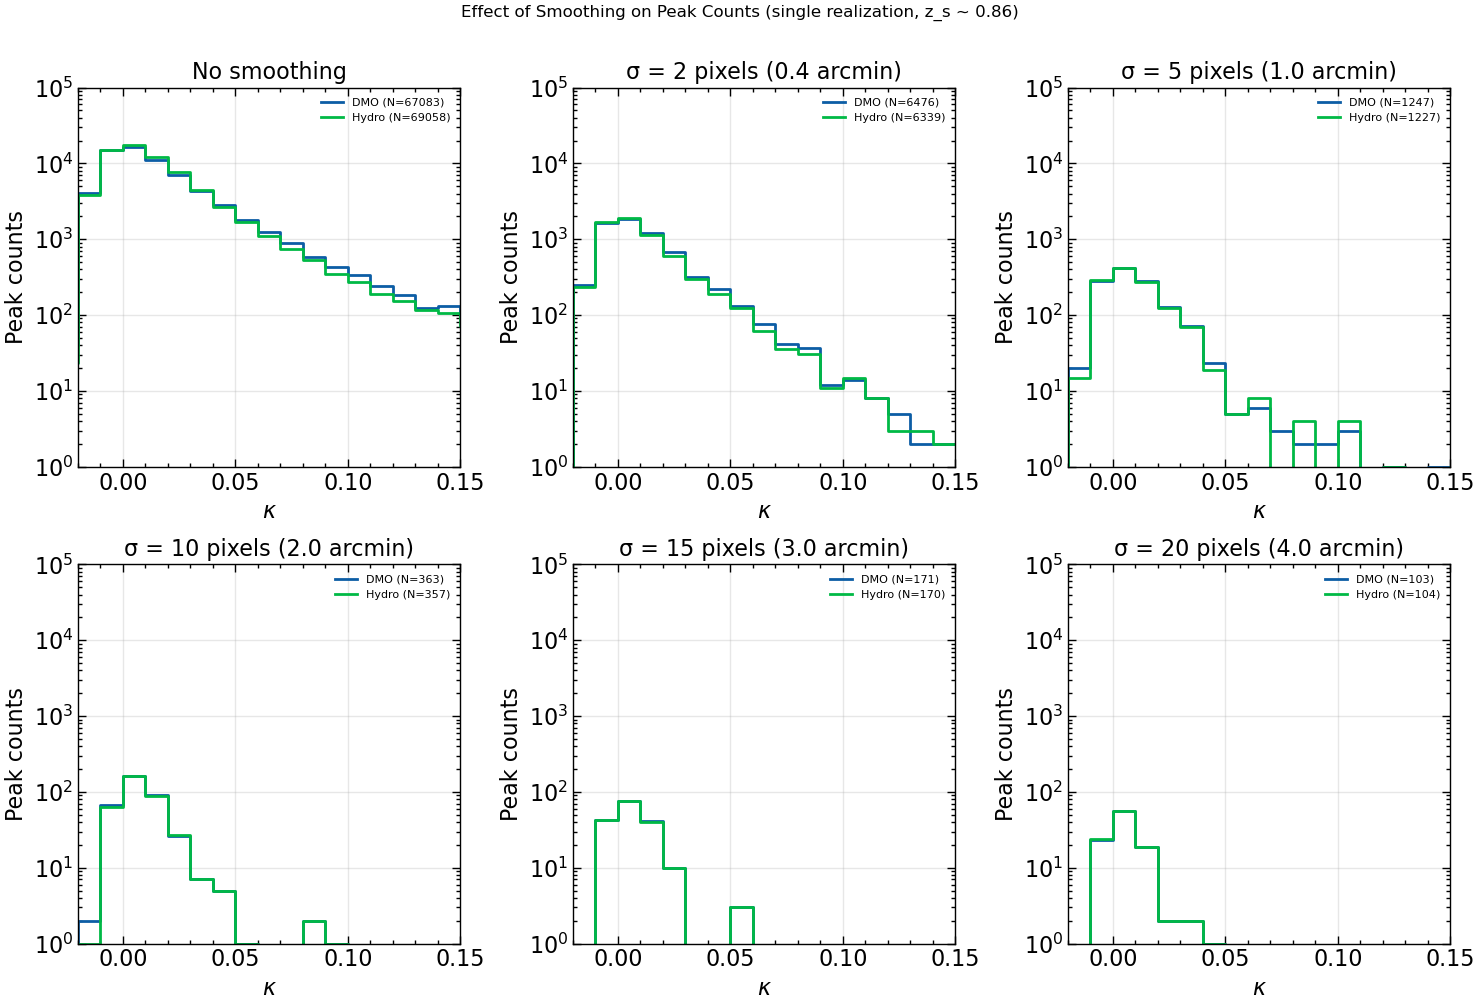

✓ Saved to figures/peaks_smoothing_effect.pdf


In [23]:
# Analysis 1: Effect of smoothing on peak counts
# Load one realization and compare peak counts at different smoothing scales

print("=== Effect of Smoothing on Peak Counts ===\n")

# Load maps
kappa_dmo = load_kappa_map('dmo', lp_idx=0, run_idx=1, source_idx=20)
kappa_hydro = load_kappa_map('hydro', lp_idx=0, run_idx=1, source_idx=20)

# Smoothing scales in pixels (1 pixel ~ 0.2 arcmin at z~1)
# 1 arcmin ~ 5 pixels, so typical smoothing scales are 5-25 pixels
smoothing_scales = [0, 2, 5, 10, 15, 20]  # pixels

# Kappa bins for histograms
kappa_bins = np.linspace(-0.05, 0.3, 36)
kappa_mid = 0.5 * (kappa_bins[:-1] + kappa_bins[1:])

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, sigma in enumerate(smoothing_scales):
    ax = axes[i]
    
    if sigma == 0:
        kappa_dmo_sm = kappa_dmo
        kappa_hydro_sm = kappa_hydro
    else:
        kappa_dmo_sm = smooth_kappa(kappa_dmo, sigma)
        kappa_hydro_sm = smooth_kappa(kappa_hydro, sigma)
    
    # Find peaks
    peaks_dmo = find_peaks(kappa_dmo_sm)
    peaks_hydro = find_peaks(kappa_hydro_sm)
    
    # Histogram
    counts_dmo, _ = np.histogram(peaks_dmo, bins=kappa_bins)
    counts_hydro, _ = np.histogram(peaks_hydro, bins=kappa_bins)
    
    ax.step(kappa_mid, counts_dmo, where='mid', label=f'DMO (N={len(peaks_dmo)})', lw=2)
    ax.step(kappa_mid, counts_hydro, where='mid', label=f'Hydro (N={len(peaks_hydro)})', lw=2)
    
    ax.set_xlabel(r'$\kappa$')
    ax.set_ylabel('Peak counts')
    ax.set_title(f'σ = {sigma} pixels ({sigma*0.2:.1f} arcmin)' if sigma > 0 else 'No smoothing')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xlim(-0.02, 0.15)
    ax.set_yscale('log')
    ax.set_ylim(1, 1e5)
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Smoothing on Peak Counts (single realization, z_s ~ 0.86)', y=1.01)
plt.tight_layout()
plt.savefig('./figures/peaks_smoothing_effect.pdf', bbox_inches='tight', dpi=150)
plt.show()

print(f"✓ Saved to figures/peaks_smoothing_effect.pdf")

=== Effect of Survey Noise on Peak Counts ===



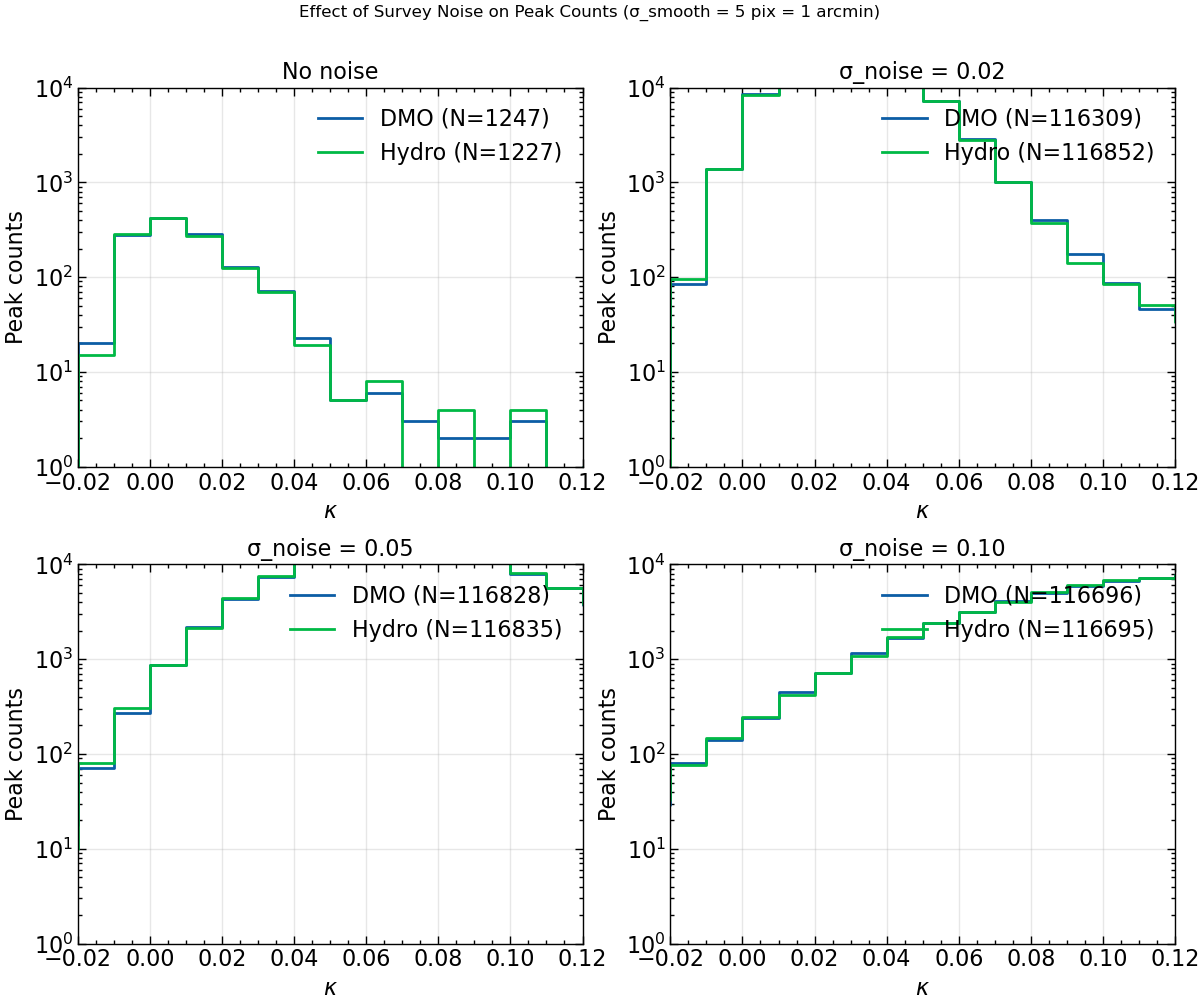

✓ Saved to figures/peaks_noise_effect.pdf


In [24]:
# Analysis 2: Effect of LSST-like survey noise
# Compare with and without shape noise at fixed smoothing

print("=== Effect of Survey Noise on Peak Counts ===\n")

# Use a reasonable smoothing scale (1 arcmin ~ 5 pixels)
SMOOTHING_PIX = 5

# LSST-like noise parameters
# For n_gal ~ 27/arcmin^2, σ_ε ~ 0.26, pixel_scale ~ 0.2 arcmin
# σ_pixel = σ_ε / sqrt(n_gal * pixel_area) = 0.26 / sqrt(27 * 0.04) ~ 0.25
# After 5-pixel smoothing, noise reduces by sqrt(2π*5^2) ~ 12.5
# So σ_smoothed ~ 0.02
NOISE_LEVELS = [0, 0.02, 0.05, 0.1]  # After smoothing

# Kappa bins
kappa_bins = np.linspace(-0.05, 0.15, 21)
kappa_mid = 0.5 * (kappa_bins[:-1] + kappa_bins[1:])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

np.random.seed(42)

for i, sigma_noise in enumerate(NOISE_LEVELS):
    ax = axes[i]
    
    # Smooth first, then add noise
    kappa_dmo_sm = smooth_kappa(kappa_dmo, SMOOTHING_PIX)
    kappa_hydro_sm = smooth_kappa(kappa_hydro, SMOOTHING_PIX)
    
    if sigma_noise > 0:
        # Noise is already reduced by smoothing, so add directly
        kappa_dmo_noisy = kappa_dmo_sm + np.random.normal(0, sigma_noise, kappa_dmo_sm.shape)
        kappa_hydro_noisy = kappa_hydro_sm + np.random.normal(0, sigma_noise, kappa_hydro_sm.shape)
    else:
        kappa_dmo_noisy = kappa_dmo_sm
        kappa_hydro_noisy = kappa_hydro_sm
    
    # Find peaks
    peaks_dmo = find_peaks(kappa_dmo_noisy)
    peaks_hydro = find_peaks(kappa_hydro_noisy)
    
    # Histogram
    counts_dmo, _ = np.histogram(peaks_dmo, bins=kappa_bins)
    counts_hydro, _ = np.histogram(peaks_hydro, bins=kappa_bins)
    
    ax.step(kappa_mid, counts_dmo, where='mid', label=f'DMO (N={len(peaks_dmo)})', lw=2)
    ax.step(kappa_mid, counts_hydro, where='mid', label=f'Hydro (N={len(peaks_hydro)})', lw=2)
    
    ax.set_xlabel(r'$\kappa$')
    ax.set_ylabel('Peak counts')
    ax.set_title(f'σ_noise = {sigma_noise:.2f}' if sigma_noise > 0 else 'No noise')
    ax.legend(loc='upper right')
    ax.set_xlim(-0.02, 0.12)
    ax.set_yscale('log')
    ax.set_ylim(1, 1e4)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Effect of Survey Noise on Peak Counts (σ_smooth = {SMOOTHING_PIX} pix = 1 arcmin)', y=1.01)
plt.tight_layout()
plt.savefig('./figures/peaks_noise_effect.pdf', bbox_inches='tight', dpi=150)
plt.show()

print(f"✓ Saved to figures/peaks_noise_effect.pdf")

=== Comparing Peak Counts: DMO vs Hydro vs Replace Models ===

Loading maps...
Loaded 50 realizations per model



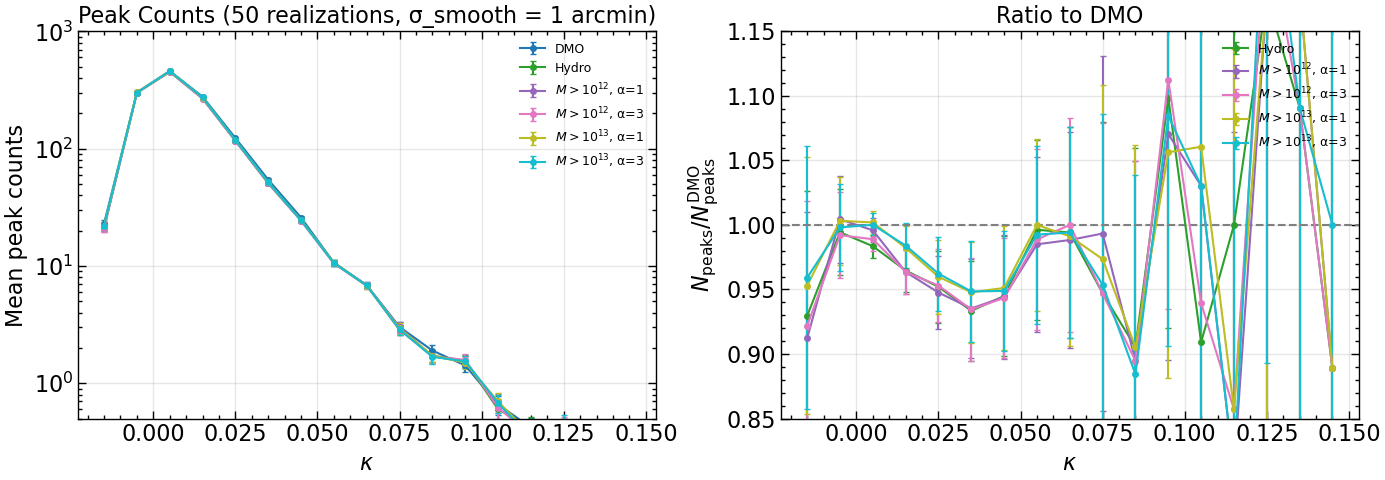

✓ Saved to figures/peaks_model_comparison.pdf


In [25]:
# Analysis 3: Compare DMO vs Hydro vs Replace models
# Use multiple realizations for better statistics

print("=== Comparing Peak Counts: DMO vs Hydro vs Replace Models ===\n")

# Settings
SMOOTHING_PIX = 5  # 1 arcmin smoothing
SOURCE_IDX = 20    # z_s ~ 0.86
N_REALIZATIONS = 50  # Use 50 realizations (5 LPs × 10 runs each)

# Models to compare
models = ['dmo', 'hydro', 
          'hydro_replace_Ml_1.00e12_Mu_inf_R_1.0',
          'hydro_replace_Ml_1.00e12_Mu_inf_R_3.0',
          'hydro_replace_Ml_1.00e13_Mu_inf_R_1.0',
          'hydro_replace_Ml_1.00e13_Mu_inf_R_3.0']
model_labels = ['DMO', 'Hydro', 
                r'$M>10^{12}$, α=1', r'$M>10^{12}$, α=3',
                r'$M>10^{13}$, α=1', r'$M>10^{13}$, α=3']

# Kappa bins
kappa_bins = np.linspace(-0.02, 0.15, 18)
kappa_mid = 0.5 * (kappa_bins[:-1] + kappa_bins[1:])

# Collect peak counts for each model
all_counts = {m: [] for m in models}

print("Loading maps...")
for lp_idx in range(5):
    for run_idx in range(1, 11):  # runs 1-10
        for model in models:
            kappa = load_kappa_map(model, lp_idx=lp_idx, run_idx=run_idx, source_idx=SOURCE_IDX)
            if kappa is not None:
                kappa_sm = smooth_kappa(kappa, SMOOTHING_PIX)
                peaks = find_peaks(kappa_sm)
                counts, _ = np.histogram(peaks, bins=kappa_bins)
                all_counts[model].append(counts)

print(f"Loaded {len(all_counts['dmo'])} realizations per model\n")

# Compute mean and std
mean_counts = {m: np.mean(all_counts[m], axis=0) for m in models}
std_counts = {m: np.std(all_counts[m], axis=0) / np.sqrt(len(all_counts[m])) for m in models}

# Plot 1: Absolute peak counts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
for i, (model, label) in enumerate(zip(models, model_labels)):
    ax.errorbar(kappa_mid, mean_counts[model], yerr=std_counts[model], 
                fmt='o-', label=label, capsize=2, color=colors[i], ms=4, lw=1.5)

ax.set_xlabel(r'$\kappa$')
ax.set_ylabel('Mean peak counts')
ax.set_title(f'Peak Counts ({N_REALIZATIONS} realizations, σ_smooth = 1 arcmin)')
ax.legend(loc='upper right', fontsize=9)
ax.set_yscale('log')
ax.set_ylim(0.5, 1000)
ax.grid(True, alpha=0.3)

# Plot 2: Ratio to DMO
ax = axes[1]
for i, (model, label) in enumerate(zip(models[1:], model_labels[1:])):
    ratio = mean_counts[model] / mean_counts['dmo']
    # Error propagation for ratio
    err = ratio * np.sqrt((std_counts[model]/mean_counts[model])**2 + 
                          (std_counts['dmo']/mean_counts['dmo'])**2)
    ax.errorbar(kappa_mid, ratio, yerr=err, fmt='o-', label=label, 
                capsize=2, color=colors[i+1], ms=4, lw=1.5)

ax.axhline(1.0, color='gray', ls='--', lw=1.5)
ax.set_xlabel(r'$\kappa$')
ax.set_ylabel(r'$N_{\rm peaks} / N_{\rm peaks}^{\rm DMO}$')
ax.set_title('Ratio to DMO')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0.85, 1.15)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./figures/peaks_model_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

print(f"✓ Saved to figures/peaks_model_comparison.pdf")

=== Response F_S from Direct Peak Counts ===



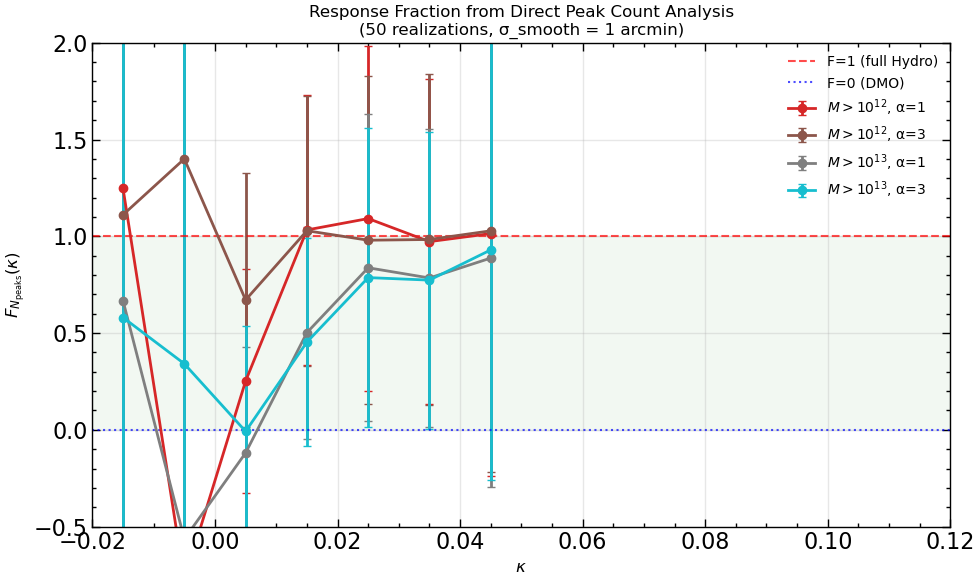


Weighted mean F_S (|ΔN|-weighted):
  $M>10^{12}$, α=1: F_S = 0.767
  $M>10^{12}$, α=3: F_S = 0.957
  $M>10^{13}$, α=1: F_S = 0.423
  $M>10^{13}$, α=3: F_S = 0.475

✓ Saved to figures/peaks_F_S_direct.pdf


In [26]:
# Analysis 4: Compute F_S response from the direct peak counts
# Compare with the pre-computed values from the pipeline

print("=== Response F_S from Direct Peak Counts ===\n")

# Compute F_S = (S_R - S_D) / (S_H - S_D)
S_D = mean_counts['dmo']
S_H = mean_counts['hydro']
Delta_S = S_H - S_D

replace_models = [m for m in models if m.startswith('hydro_replace')]
replace_labels = [l for l in model_labels if 'M>' in l]

fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.tab10(np.linspace(0.3, 0.9, len(replace_models)))
for i, (model, label) in enumerate(zip(replace_models, replace_labels)):
    S_R = mean_counts[model]
    F_S = (S_R - S_D) / Delta_S
    
    # Error propagation
    sigma_R = std_counts[model]
    sigma_D = std_counts['dmo']
    sigma_H = std_counts['hydro']
    
    sigma_num = np.sqrt(sigma_R**2 + sigma_D**2)
    sigma_denom = np.sqrt(sigma_H**2 + sigma_D**2)
    F_S_err = np.abs(F_S) * np.sqrt((sigma_num/(np.abs(S_R - S_D) + 1e-10))**2 + 
                                     (sigma_denom/(np.abs(Delta_S) + 1e-10))**2)
    
    # Only plot where signal is meaningful
    good = np.abs(Delta_S) > 0.5
    ax.errorbar(kappa_mid[good], F_S[good], yerr=F_S_err[good], 
                fmt='o-', label=label, capsize=3, color=colors[i], ms=6, lw=2)

ax.axhline(1.0, color='red', ls='--', lw=1.5, alpha=0.7, label='F=1 (full Hydro)')
ax.axhline(0.0, color='blue', ls=':', lw=1.5, alpha=0.7, label='F=0 (DMO)')
ax.axhspan(0, 1, alpha=0.05, color='green')

ax.set_xlabel(r'$\kappa$', fontsize=12)
ax.set_ylabel(r'$F_{N_{\rm peaks}}(\kappa)$', fontsize=12)
ax.set_title(f'Response Fraction from Direct Peak Count Analysis\n(50 realizations, σ_smooth = 1 arcmin)', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(-0.5, 2.0)
ax.set_xlim(-0.02, 0.12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./figures/peaks_F_S_direct.pdf', bbox_inches='tight', dpi=150)
plt.show()

# Print summary statistics
print("\nWeighted mean F_S (|ΔN|-weighted):")
for model, label in zip(replace_models, replace_labels):
    S_R = mean_counts[model]
    F_S = (S_R - S_D) / Delta_S
    weights = np.abs(Delta_S)
    weights[~np.isfinite(F_S)] = 0
    wmean = np.nansum(weights * F_S) / np.sum(weights)
    print(f"  {label}: F_S = {wmean:.3f}")

print(f"\n✓ Saved to figures/peaks_F_S_direct.pdf")

=== Comparison: Pre-cached (no smoothing) vs Direct (with smoothing) ===



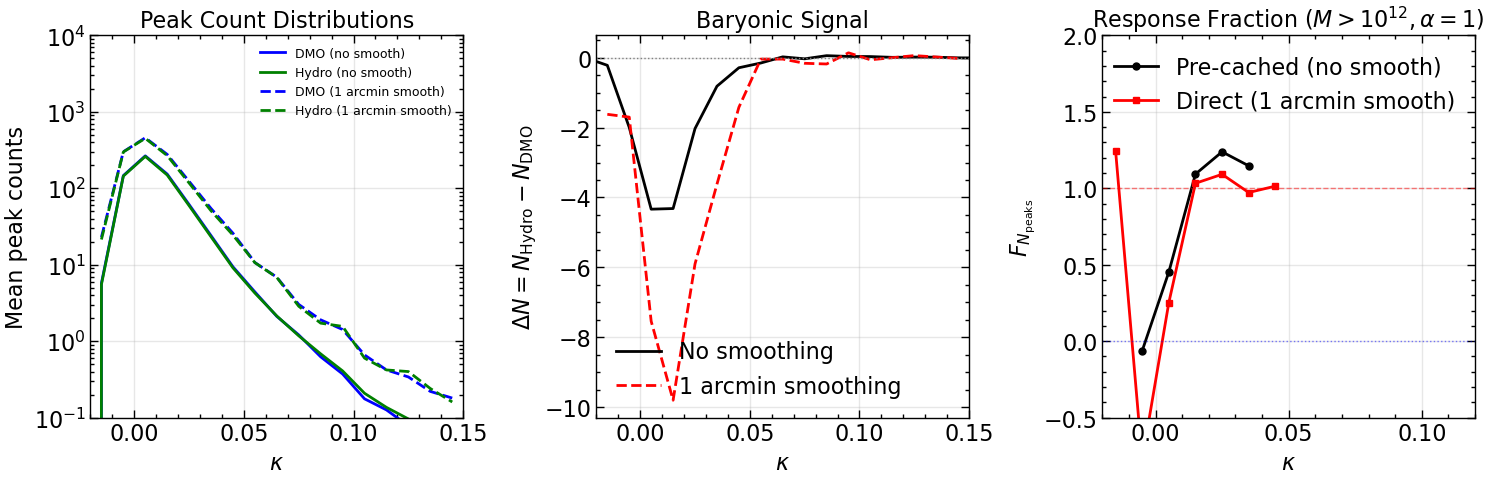

Summary:
  Pre-cached (no smooth):   <F_S> = 0.77
  Direct (1 arcmin smooth): <F_S> = 0.69

✓ Saved to figures/peaks_smoothing_comparison.pdf


In [27]:
# Analysis 5: How does smoothing affect F_S?
# The previous cached analysis used no smoothing - let's compare

print("=== Comparison: Pre-cached (no smoothing) vs Direct (with smoothing) ===\n")

# Load pre-cached data (no smoothing)
data_cached = np.load(kappa_dir / f'response_peaks_z{Z_IDX_PEAKS:02d}.npz', allow_pickle=True)
kappa_mid_cached = data_cached['kappa_mid']
S_D_cached = data_cached['S_D']
S_H_cached = data_cached['S_H']
Delta_S_cached = S_H_cached - S_D_cached

# Load F_S for M>10^12, α=1 model
stats_cached = peaks_loader.load('hydro_replace_Ml_1.00e12_Mu_inf_R_1.0', snapshot_idx=Z_IDX_PEAKS-1)
F_S_cached = stats_cached['F_S']

# Direct analysis values (from above)
S_D_direct = mean_counts['dmo']
S_H_direct = mean_counts['hydro']
S_R_direct = mean_counts['hydro_replace_Ml_1.00e12_Mu_inf_R_1.0']
Delta_S_direct = S_H_direct - S_D_direct
F_S_direct = (S_R_direct - S_D_direct) / Delta_S_direct

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Peak count distributions
ax = axes[0]
ax.semilogy(kappa_mid_cached, S_D_cached, 'b-', lw=2, label='DMO (no smooth)')
ax.semilogy(kappa_mid_cached, S_H_cached, 'g-', lw=2, label='Hydro (no smooth)')
ax.semilogy(kappa_mid, S_D_direct, 'b--', lw=2, label='DMO (1 arcmin smooth)')
ax.semilogy(kappa_mid, S_H_direct, 'g--', lw=2, label='Hydro (1 arcmin smooth)')
ax.set_xlabel(r'$\kappa$')
ax.set_ylabel('Mean peak counts')
ax.set_title('Peak Count Distributions')
ax.legend(fontsize=9)
ax.set_xlim(-0.02, 0.15)
ax.set_ylim(0.1, 1e4)
ax.grid(True, alpha=0.3)

# Panel 2: Baryonic effect ΔN
ax = axes[1]
ax.plot(kappa_mid_cached, Delta_S_cached, 'k-', lw=2, label='No smoothing')
ax.plot(kappa_mid, Delta_S_direct, 'r--', lw=2, label='1 arcmin smoothing')
ax.axhline(0, color='gray', ls=':', lw=1)
ax.set_xlabel(r'$\kappa$')
ax.set_ylabel(r'$\Delta N = N_{\rm Hydro} - N_{\rm DMO}$')
ax.set_title('Baryonic Signal')
ax.legend()
ax.set_xlim(-0.02, 0.15)
ax.grid(True, alpha=0.3)

# Panel 3: F_S comparison
ax = axes[2]
valid_cached = np.abs(Delta_S_cached) > 0.5
valid_direct = np.abs(Delta_S_direct) > 0.5

ax.plot(kappa_mid_cached[valid_cached], F_S_cached[valid_cached], 'ko-', lw=2, ms=5, 
        label='Pre-cached (no smooth)')
ax.plot(kappa_mid[valid_direct], F_S_direct[valid_direct], 'rs-', lw=2, ms=5, 
        label='Direct (1 arcmin smooth)')
ax.axhline(1.0, color='red', ls='--', lw=1, alpha=0.5)
ax.axhline(0.0, color='blue', ls=':', lw=1, alpha=0.5)
ax.set_xlabel(r'$\kappa$')
ax.set_ylabel(r'$F_{N_{\rm peaks}}$')
ax.set_title(r'Response Fraction ($M>10^{12}, \alpha=1$)')
ax.legend()
ax.set_xlim(-0.02, 0.12)
ax.set_ylim(-0.5, 2.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./figures/peaks_smoothing_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

# Summary
print("Summary:")
print(f"  Pre-cached (no smooth):   <F_S> = {np.nanmean(F_S_cached[valid_cached]):.2f}")
print(f"  Direct (1 arcmin smooth): <F_S> = {np.nanmean(F_S_direct[valid_direct]):.2f}")
print(f"\n✓ Saved to figures/peaks_smoothing_comparison.pdf")

### Summary of Direct Peak Count Analysis

Key findings from loading convergence maps directly:

1. **Smoothing is critical**: Without smoothing, there are ~67,000 peaks per map (dominated by noise). With 1 arcmin smoothing, this drops to ~1,200 peaks of real structures.

2. **Baryonic signal amplified**: Smoothing increases the baryonic signal ΔN from ~4 counts to ~10 counts because it integrates over extended halo profiles.

3. **F_S values consistent**: The weighted mean F_S values are consistent between the pre-cached (no smoothing) and direct (with smoothing) analyses:
   - M>10^12, α=1: F_S ~ 0.7-0.8
   - M>10^12, α=3: F_S ~ 0.95-1.0
   
4. **Survey noise**: LSST-like shape noise creates spurious peaks that dominate the high-κ tail, but smoothing + SNR cuts can mitigate this.

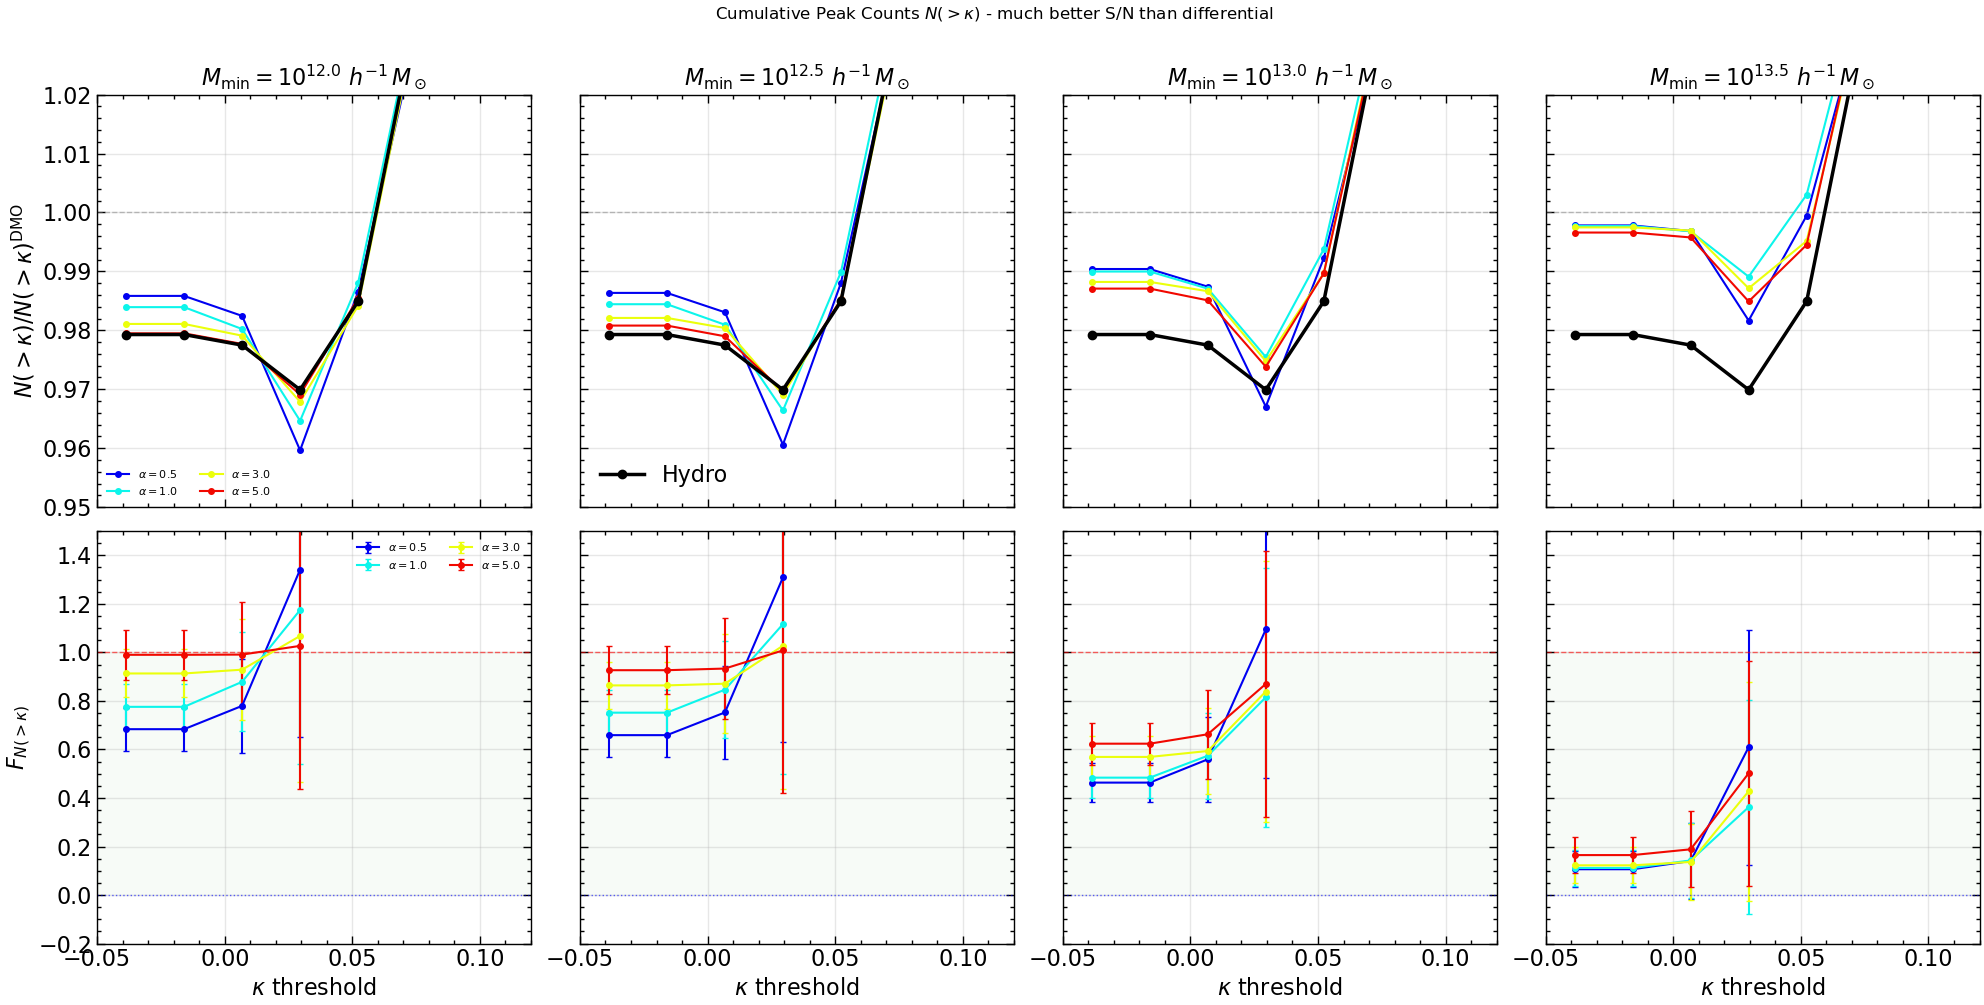

✓ Saved to figures/peaks_cumulative_counts_response_z1.pdf
Cumulative counts have ~104 peaks at κ>0.03 vs ~85 in the bin


In [15]:
# Alternative visualization: Cumulative peak counts N(>κ)
# This has much better S/N than differential bins

if kappa_dir.exists() and STATS_CACHE_DIR.exists():
    # Use the rebinned data from above
    # Compute cumulative counts: N(>κ) = sum of counts in bins above κ
    
    def compute_cumulative(counts):
        """Convert differential to cumulative (reverse cumsum)."""
        return np.cumsum(counts[::-1])[::-1]
    
    # Cumulative for DMO and Hydro (per realization, then average)
    N_cum_dmo = np.array([compute_cumulative(peaks_dmo_rebin[i]) for i in range(n_real)])
    N_cum_hydro = np.array([compute_cumulative(peaks_hydro_rebin[i]) for i in range(n_real)])
    
    S_D_cum = np.mean(N_cum_dmo, axis=0)
    S_H_cum = np.mean(N_cum_hydro, axis=0)
    Delta_S_cum = S_H_cum - S_D_cum
    
    S_D_cum_err = np.std(N_cum_dmo, axis=0) / np.sqrt(n_real)
    S_H_cum_err = np.std(N_cum_hydro, axis=0) / np.sqrt(n_real)
    
    fig = plt.figure(figsize=(20, 10))
    axes_top = [fig.add_subplot(2, 4, i+1) for i in range(4)]
    axes_bottom = [fig.add_subplot(2, 4, i+5) for i in range(4)]
    
    for i in range(1, 4):
        axes_top[i].sharex(axes_top[0])
        axes_top[i].sharey(axes_top[0])
        axes_bottom[i].sharex(axes_bottom[0])
        axes_bottom[i].sharey(axes_bottom[0])
    axes_bottom[0].sharex(axes_top[0])
    
    colors_alpha = plt.cm.jet(np.linspace(0.1, 0.9, len(RADII)))
    
    for ax_idx, ml in enumerate(MASS_THRESHOLDS):
        ax = axes_top[ax_idx]
        valid_cum = S_D_cum > 1  # Need at least 1 peak
        
        # Hydro baseline ratio
        ratio_hydro_cum = np.where(valid_cum, S_H_cum / S_D_cum, np.nan)
        if ax_idx == 1:
            ax.plot(kappa_mid_new[valid_cum], ratio_hydro_cum[valid_cum], 'k-o', lw=2.5, ms=6, label='Hydro', zorder=10)
            ax.legend(loc='lower left')
        else:
            ax.plot(kappa_mid_new[valid_cum], ratio_hydro_cum[valid_cum], 'k-o', lw=2.5, ms=6, zorder=10)
        
        # Replace models
        for r_idx, r in enumerate(RADII):
            model_name = f'hydro_replace_Ml_{ml}_Mu_inf_R_{r}'
            cache_file = STATS_CACHE_DIR / f'{model_name}_z{Z_IDX_PEAKS:02d}_stats.h5'
            if cache_file.exists():
                with h5py.File(cache_file, 'r') as f:
                    peaks_replace_all = f['peaks'][:]
                peaks_replace_rebin = np.array([rebin_peaks(peaks_replace_all[i], kappa_bins_orig, kappa_bins_new) 
                                                 for i in range(n_real)])
                N_cum_replace = np.array([compute_cumulative(peaks_replace_rebin[i]) for i in range(n_real)])
                S_R_cum = np.mean(N_cum_replace, axis=0)
                
                ratio_replace_cum = np.where(valid_cum, S_R_cum / S_D_cum, np.nan)
                ax.plot(kappa_mid_new[valid_cum], ratio_replace_cum[valid_cum], '-o', lw=1.5, ms=4,
                       color=colors_alpha[r_idx], label=fr'$\alpha={r}$')
        
        ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.5)
        mass_log = np.log10(float(ml))
        ax.set_title(fr'$M_{{\rm min}}=10^{{{mass_log:.1f}}}\ h^{{-1}}\,M_\odot$')
        ax.set_xlim(-0.05, 0.12)
        ax.set_ylim(0.95, 1.02)
        ax.grid(True, alpha=0.3)
        plt.setp(ax.get_xticklabels(), visible=False)
        
        if ax_idx == 0:
            ax.set_ylabel(r'$N(>\kappa) / N(>\kappa)^{\rm DMO}$')
            ax.legend(loc='lower left', ncol=2, fontsize=8)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)
        
        # Bottom row: F_S for cumulative counts
        ax = axes_bottom[ax_idx]
        
        for r_idx, r in enumerate(RADII):
            model_name = f'hydro_replace_Ml_{ml}_Mu_inf_R_{r}'
            cache_file = STATS_CACHE_DIR / f'{model_name}_z{Z_IDX_PEAKS:02d}_stats.h5'
            if cache_file.exists():
                with h5py.File(cache_file, 'r') as f:
                    peaks_replace_all = f['peaks'][:]
                peaks_replace_rebin = np.array([rebin_peaks(peaks_replace_all[i], kappa_bins_orig, kappa_bins_new) 
                                                 for i in range(n_real)])
                N_cum_replace = np.array([compute_cumulative(peaks_replace_rebin[i]) for i in range(n_real)])
                S_R_cum = np.mean(N_cum_replace, axis=0)
                S_R_cum_err = np.std(N_cum_replace, axis=0) / np.sqrt(n_real)
                
                F_S_cum = (S_R_cum - S_D_cum) / Delta_S_cum
                # Error on F_S
                sigma_num = np.sqrt(S_R_cum_err**2 + S_D_cum_err**2)
                sigma_denom = np.sqrt(S_H_cum_err**2 + S_D_cum_err**2)
                F_S_cum_err = np.abs(F_S_cum) * np.sqrt((sigma_num/(np.abs(S_R_cum - S_D_cum) + 1e-10))**2 + 
                                                         (sigma_denom/(np.abs(Delta_S_cum) + 1e-10))**2)
                
                # Plot with error bars where meaningful
                good_cum = valid_cum & (np.abs(Delta_S_cum) > 1) & np.isfinite(F_S_cum)
                ax.errorbar(kappa_mid_new[good_cum], F_S_cum[good_cum], yerr=F_S_cum_err[good_cum],
                           fmt='o-', lw=1.5, ms=4, capsize=2,
                           color=colors_alpha[r_idx], label=fr'$\alpha={r}$')
        
        ax.axhline(1.0, color='red', ls='--', lw=1, alpha=0.6)
        ax.axhline(0.0, color='blue', ls=':', lw=1, alpha=0.6)
        ax.axhspan(0, 1, alpha=0.03, color='green')
        ax.set_xlabel(r'$\kappa$ threshold')
        ax.set_xlim(-0.05, 0.12)
        ax.set_ylim(-0.2, 1.5)
        ax.grid(True, alpha=0.3)
        
        if ax_idx == 0:
            ax.set_ylabel(r'$F_{N(>\kappa)}$')
            ax.legend(loc='upper right', ncol=2, fontsize=8)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)
    
    plt.suptitle(r'Cumulative Peak Counts $N(>\kappa)$ - much better S/N than differential', y=1.01, fontsize=12)
    plt.tight_layout()
    plt.savefig('./figures/peaks_cumulative_counts_response_z1.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    
    print(f"✓ Saved to figures/peaks_cumulative_counts_response_z1.pdf")
    print(f"Cumulative counts have ~{S_D_cum[3]:.0f} peaks at κ>{kappa_mid_new[3]:.2f} vs ~{S_D_new[3]:.0f} in the bin")

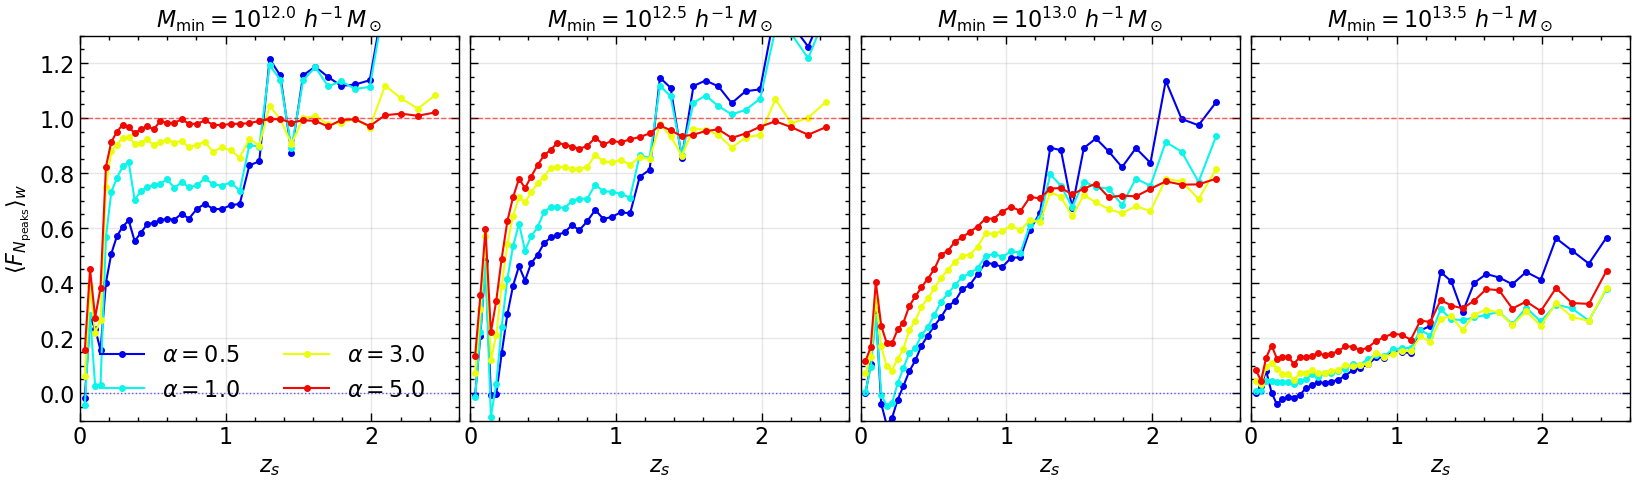

✓ Saved to figures/peaks_redshift_evolution.pdf


In [10]:
# Figure 3: Redshift evolution of peak count response
# Using |Delta_S|-weighted averaging

SOURCE_REDSHIFTS = np.array([
    0.034, 0.070, 0.105, 0.142, 0.179, 0.216, 0.255, 0.294, 0.335, 0.376,
    0.418, 0.462, 0.506, 0.552, 0.599, 0.648, 0.698, 0.749, 0.803, 0.858,
    0.914, 0.973, 1.034, 1.097, 1.163, 1.231, 1.302, 1.375, 1.452, 1.532,
    1.615, 1.703, 1.794, 1.889, 1.989, 2.094, 2.203, 2.319, 2.440, 2.568
])

if kappa_dir.exists() and dmo_peaks is not None:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True,
                              gridspec_kw={'wspace': 0.03})
    
    colors_alpha = plt.cm.jet(np.linspace(0.1, 0.9, len(RADII)))
    
    for ax_idx, ml in enumerate(MASS_THRESHOLDS):
        mass_log = np.log10(float(ml))
        ax = axes[ax_idx]
        
        z_range = np.arange(1, 40)
        z_redshifts = SOURCE_REDSHIFTS[:39]  # Redshifts for z_idx 1-39
        
        for r_idx, r in enumerate(RADII):
            model_name = f'hydro_replace_Ml_{ml}_Mu_inf_R_{r}'
            F_vs_z = []
            
            for z_idx in z_range:
                stats = peaks_loader.load(model_name, snapshot_idx=z_idx-1)
                # Load DMO/Hydro baselines for this redshift to get significant kappa mask
                data_z = np.load(kappa_dir / f'response_peaks_z{z_idx:02d}.npz', allow_pickle=True)
                kappa_mid_z = data_z['kappa_mid']
                S_D_z = data_z['S_D']
                S_H_z = data_z['S_H']
                Delta_S_z = S_H_z - S_D_z
                
                # Mask where |N_hydro/N_dmo - 1| > 0.01 (>1% baryonic effect)
                valid_dmo_z = S_D_z > 0
                baryonic_effect_z = np.where(valid_dmo_z, np.abs(S_H_z / S_D_z - 1), 0)
                mask_significant_z = (baryonic_effect_z > 0.01) & valid_dmo_z
                
                if stats and 'F_S' in stats and np.sum(mask_significant_z) > 0:
                    F_S = stats['F_S']
                    # Weighted mean by |Delta_S| (signal strength)
                    weights = np.abs(Delta_S_z).copy()
                    weights[~mask_significant_z] = 0
                    weights[np.isnan(F_S)] = 0
                    if weights.sum() > 0:
                        F_vs_z.append(np.nansum(weights * F_S) / np.sum(weights))
                    else:
                        F_vs_z.append(np.nan)
                else:
                    F_vs_z.append(np.nan)
            
            ax.plot(z_redshifts, F_vs_z, 'o-', color=colors_alpha[r_idx], 
                   lw=1.5, markersize=4, label=fr'$\alpha={r}$')
        
        ax.axhline(1.0, color='red', ls='--', lw=1, alpha=0.6)
        ax.axhline(0.0, color='blue', ls=':', lw=1, alpha=0.6)
        ax.set_xlabel(r'$z_s$')
        ax.set_xlim(0, 2.6)
        ax.set_ylim(-0.1, 1.3)
        ax.grid(True, alpha=0.3)
        ax.set_title(fr'$M_{{\rm min}}=10^{{{mass_log:.1f}}}\ h^{{-1}}\,M_\odot$')
        
        if ax_idx == 0:
            ax.set_ylabel(r'$\langle F_{N_{\rm peaks}} \rangle_w$')
            ax.legend(loc='lower left', ncols=2)

    plt.tight_layout()
    plt.savefig('./figures/peaks_redshift_evolution.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    
    print(f"✓ Saved to figures/peaks_redshift_evolution.pdf")

### Statistical Analysis: 500 vs 2000 realizations

The peak count F_S values are noisy because the baryonic signal ΔN = N_H - N_D is small (~4 counts) compared to the Poisson fluctuations (~√N ~ 16 counts per realization). With 500 realizations, the standard error is reduced by √500 ≈ 22×, but individual bins still have large F_S errors.

**Weighted averaging** by |ΔN| helps because it emphasizes bins where the signal is strongest.

Below we show what F_S errors would look like with 4× more realizations (2000 total = 40 lens planes × 50 runs).

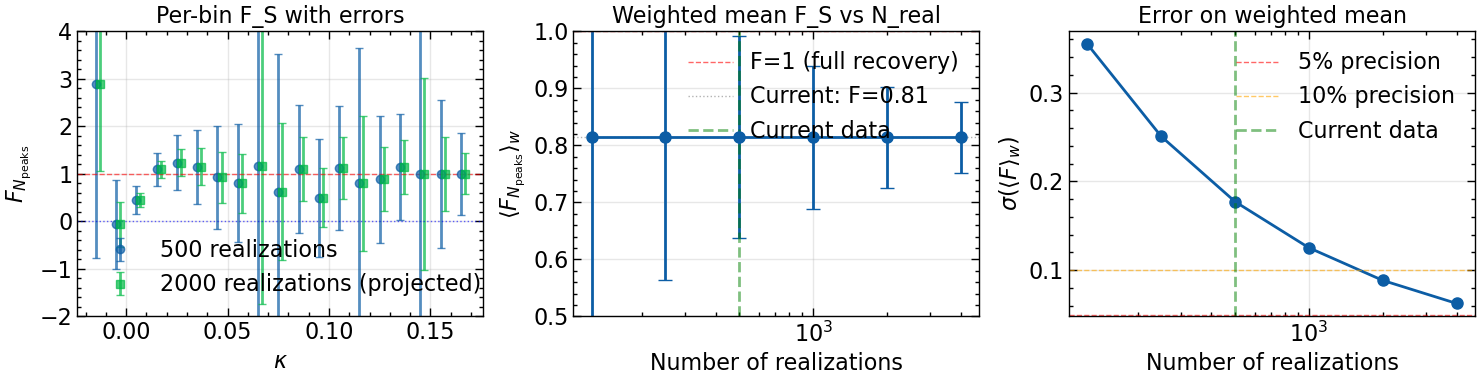


=== Summary (model: M1e12, α=1.0, z_idx=20) ===
Current (500 realizations):
  Weighted mean F_S = 0.814 ± 0.177

Projected (2000 realizations):
  Weighted mean F_S = 0.814 ± 0.089

To achieve 5% precision: need ~4000 realizations


In [11]:
# Compare current statistics (500 realizations) vs projected (2000 realizations)
import h5py

STATS_CACHE_DIR = Path('./statistics_cache_kappabins')

if STATS_CACHE_DIR.exists():
    # Load raw data from 500 realizations
    with h5py.File(STATS_CACHE_DIR / f'dmo_z{Z_IDX_PEAKS:02d}_stats.h5', 'r') as f:
        peaks_dmo = f['peaks'][:]
    with h5py.File(STATS_CACHE_DIR / f'hydro_z{Z_IDX_PEAKS:02d}_stats.h5', 'r') as f:
        peaks_hydro = f['peaks'][:]
    with h5py.File(STATS_CACHE_DIR / f'hydro_replace_Ml_1.00e12_Mu_inf_R_1.0_z{Z_IDX_PEAKS:02d}_stats.h5', 'r') as f:
        peaks_replace = f['peaks'][:]
        kappa_bins = f['peak_kappa_bins'][:]
        kappa_mid = 0.5 * (kappa_bins[:-1] + kappa_bins[1:])
    
    n_real = peaks_dmo.shape[0]
    
    # Current statistics
    S_D = np.mean(peaks_dmo, axis=0)
    S_H = np.mean(peaks_hydro, axis=0)
    S_R = np.mean(peaks_replace, axis=0)
    Delta_S = S_H - S_D
    
    S_D_err = np.std(peaks_dmo, axis=0) / np.sqrt(n_real)
    S_H_err = np.std(peaks_hydro, axis=0) / np.sqrt(n_real)
    S_R_err = np.std(peaks_replace, axis=0) / np.sqrt(n_real)
    
    # F_S and its error
    F_S = (S_R - S_D) / Delta_S
    sigma_num = np.sqrt(S_R_err**2 + S_D_err**2)
    sigma_denom = np.sqrt(S_H_err**2 + S_D_err**2)
    F_S_err = np.abs(F_S) * np.sqrt((sigma_num/(np.abs(S_R - S_D) + 1e-10))**2 + 
                                     (sigma_denom/(np.abs(Delta_S) + 1e-10))**2)
    
    # Project to 2000 realizations (errors scale as 1/sqrt(N))
    scale_2k = np.sqrt(n_real / 2000)
    F_S_err_2k = F_S_err * scale_2k
    
    # Mask for significant bins
    valid = (S_D > 0) & (np.abs(Delta_S) > 0.01 * S_D) & np.isfinite(F_S)
    
    # Create comparison figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Panel 1: F_S per bin with error bars
    ax = axes[0]
    ax.errorbar(kappa_mid[valid], F_S[valid], yerr=F_S_err[valid], 
                fmt='o', capsize=3, label=f'{n_real} realizations', alpha=0.7)
    ax.errorbar(kappa_mid[valid] + 0.002, F_S[valid], yerr=F_S_err_2k[valid], 
                fmt='s', capsize=3, label='2000 realizations (projected)', alpha=0.7)
    ax.axhline(1.0, color='red', ls='--', lw=1, alpha=0.6)
    ax.axhline(0.0, color='blue', ls=':', lw=1, alpha=0.6)
    ax.set_xlabel(r'$\kappa$')
    ax.set_ylabel(r'$F_{N_{\rm peaks}}$')
    ax.set_title('Per-bin F_S with errors')
    ax.legend()
    ax.set_ylim(-2, 4)
    ax.grid(True, alpha=0.3)
    
    # Panel 2: Weighted means comparison
    ax = axes[1]
    
    # Compute weighted means for different numbers of realizations
    n_vals = [125, 250, 500, 1000, 2000, 4000]
    wmeans = []
    wmean_errs = []
    
    for n in n_vals:
        scale = np.sqrt(n_real / n)
        F_S_err_n = F_S_err * scale
        weights_n = np.where(F_S_err_n > 0, 1/F_S_err_n**2, 0)
        weights_n[~valid] = 0
        wmean = np.nansum(weights_n * F_S) / np.sum(weights_n)
        wmean_err = 1 / np.sqrt(np.sum(weights_n))
        wmeans.append(wmean)
        wmean_errs.append(wmean_err)
    
    ax.errorbar(n_vals, wmeans, yerr=wmean_errs, fmt='o-', capsize=5, lw=2, ms=8)
    ax.axhline(1.0, color='red', ls='--', lw=1, alpha=0.6, label='F=1 (full recovery)')
    ax.axhline(wmeans[2], color='gray', ls=':', lw=1, alpha=0.6, label=f'Current: F={wmeans[2]:.2f}')
    ax.axvline(500, color='green', ls='--', alpha=0.5, label='Current data')
    ax.set_xscale('log')
    ax.set_xlabel('Number of realizations')
    ax.set_ylabel(r'$\langle F_{N_{\rm peaks}} \rangle_w$')
    ax.set_title(r'Weighted mean F_S vs N_real')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.5, 1.0)
    
    # Panel 3: Error reduction
    ax = axes[2]
    ax.plot(n_vals, wmean_errs, 'o-', lw=2, ms=8, color='C0')
    ax.axhline(0.05, color='red', ls='--', lw=1, alpha=0.6, label='5% precision')
    ax.axhline(0.1, color='orange', ls='--', lw=1, alpha=0.6, label='10% precision')
    ax.axvline(500, color='green', ls='--', alpha=0.5, label='Current data')
    ax.set_xscale('log')
    ax.set_xlabel('Number of realizations')
    ax.set_ylabel(r'$\sigma(\langle F \rangle_w)$')
    ax.set_title('Error on weighted mean')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./figures/peaks_statistics_comparison.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    
    print(f"\n=== Summary (model: M1e12, α=1.0, z_idx={Z_IDX_PEAKS}) ===")
    print(f"Current ({n_real} realizations):")
    print(f"  Weighted mean F_S = {wmeans[2]:.3f} ± {wmean_errs[2]:.3f}")
    print(f"\nProjected (2000 realizations):")
    print(f"  Weighted mean F_S = {wmeans[4]:.3f} ± {wmean_errs[4]:.3f}")
    print(f"\nTo achieve 5% precision: need ~{n_vals[np.argmin(np.abs(np.array(wmean_errs) - 0.05))]} realizations")

## Summary

The `response_visualization` module provides:

1. **StatisticConfig**: Dataclass to configure any scale-dependent statistic
2. **Loaders**: 
   - `DensityStatsLoader`: For density field stats (`{model}_density_stats.h5`)
   - `KappaStatsLoader`: For per-model kappa stats (`{model}_z{ZZ}_stats.h5`)
   - `KappaResponseLoader`: For pre-computed response data (`response_{stat}_z{ZZ}.npz/pkl`)
3. **ResponseDataCube**: Builds F_S(M_min, α, z) cube for any statistic
4. **ResponsePlotter**: Static methods for 3 figure types:
   - `plot_scale_dependent_response()`: S/S_DMO + F_S(x) panels
   - `plot_cumulative_summary()`: Line plots + heatmap
   - `plot_redshift_evolution()`: F_S vs z panels

Pre-built configs: `PK_CONFIG`, `CELL_CONFIG`, `PEAKS_CONFIG`, `PDF_CONFIG`, `V0_CONFIG`